# 🔧 Predictive Maintenance Workshop: Machine Learning Pipeline for Industrial Fault Detection

## 🎯 Workshop Overview

This workshop provides a comprehensive introduction to predictive maintenance (PdM) using machine learning techniques for industrial equipment monitoring. You will develop a complete pipeline for acoustic-based fault detection in rotating machinery, from raw signal processing through model deployment.

### 🏭 Theoretical Foundation: Predictive Maintenance

Predictive maintenance represents a paradigm shift from traditional maintenance strategies:

- **🔥 Reactive Maintenance**: Corrective actions post-failure, resulting in unplanned downtime and cascading system failures
- **⏰ Preventive Maintenance**: Time-based scheduled interventions, often leading to unnecessary component replacement
- **🎯 Predictive Maintenance**: Condition-based maintenance using real-time sensor data to optimize intervention timing


### Acoustic Signal Analysis for Fault Detection

Acoustic emissions provide rich information about mechanical system health. The physical principles underlying acoustic fault detection include:

1. **Vibration Propagation**: Mechanical faults alter system dynamics, changing natural frequencies and introducing new spectral components
2. **Contact Mechanics**: Surface defects (e.g., gear tooth damage) create impulsive excitations at characteristic frequencies
3. **Signal Modulation**: Faults often manifest as amplitude or frequency modulation of carrier frequencies related to shaft rotation

### 📚 Workshop Structure (12 Steps)

1. **📦 Environment Setup**: Library configuration and imports
2. **📂 Data Loading**: Dataset discovery and initialization  
3. **🔍 Exploratory Data Analysis**: Signal, temporal, and spectrogram analysis
4. **🧠 Feature Engineering**: Hierarchical feature extraction architecture and demo
5. **🔧 Feature Pipeline & Preprocessing**: Scalable extraction and standardization
6. **💥 Naive Baseline**: Demonstrating why proper ML pipeline matters
7. **🎯 Proper Baseline**: Establishing performance benchmark with best practices
8. **🏆 Multi-Algorithm Comparison**: Testing multiple algorithms across features with performance analysis and feature importance
9. **🎭 Error Analysis**: Confusion matrix and business impact assessment
10. **🎯 Production Model Training**: Final model on complete dataset
11. **🧠 Model Persistence**: Serialization and loading for deployment
12. **🚀 Real-Time Deployment**: Live monitoring system and production interface

### Case Study: Gear Tooth Fault Detection

**Problem Statement**: Develop a multi-class classifier to categorize gear conditions using acoustic signatures, distinguishing between healthy gears and various fault types including chipped teeth.

**Performance Requirements**: 
- High recall (sensitivity) to minimize missed detections
- Controlled false positive rate to prevent maintenance disruption
- Robust performance across varying load and speed conditions

## 📦 Step 1: Library Configuration and Environment Setup

This section initializes the computational environment and imports required libraries for signal processing, machine learning, and data visualization.

In [ ]:
%%capture 
!git clone https://github.com/ManuelVea/Predictive-Maintenance-.git
!mv ./Predictive-Maintenance-*/* .
!rm -rf ./Predictive-Maintenance-*
%pip install -r requirements.txt

In [72]:
# Core computational libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Audio, display

# Configure visualization parameters
plt.style.use('default')
sns.set_palette("husl")
np.random.seed(42)  # Ensure reproducible results

# Configure Python path for custom modules
feature_pipeline_path = Path('./Preparation/Sample Preparation/Feature_extraction_pipeline').resolve()
sys.path.append(str(feature_pipeline_path))

# Import custom signal processing modules
from loader import load_long_audio
from splitters import segment_train_test
from orchestrator import run_pipeline_on_dataset

print('✅ Environment configured successfully.')
print('🔧 Custom feature extraction pipeline loaded.')

✅ Environment configured successfully.
🔧 Custom feature extraction pipeline loaded.


## 📂 Step 2: Dataset Discovery and Initialization

Data inventory and validation are critical first steps in any machine learning pipeline. This section performs systematic dataset discovery and creates a structured data catalog.

In [73]:
# Define data directory and supported audio formats
data_dir = Path("data/audio")
allowed_extensions = {".wav", ".flac", ".mp3", ".m4a", ".ogg"}


# Perform recursive file discovery and cataloging
audio_files = []
for file_path in sorted(data_dir.rglob("*")):
    if file_path.is_file() and file_path.suffix.lower() in allowed_extensions:
        audio_files.append({
            "file_path": file_path,
            "label": file_path.parent.name,  # Directory-based labeling
            "filename": file_path.name
        })

# Create structured dataset catalog
df = pd.DataFrame(audio_files)

if df.empty:
    raise ValueError(f"No audio files found. Supported formats: {allowed_extensions}")

# Dataset summary
print(f"📊 Found {len(df)} audio files")
print(df['label'].value_counts())
display(df.head(10))

📊 Found 4 audio files
label
Center_Offset    1
Chipped_Tooth    1
Good             1
Vertical_Wear    1
Name: count, dtype: int64


,file_path,label,filename
0,data/audio/Center_Offset/20251021_174838.wav,Center_Offset,20251021_174838.wav
1,data/audio/Chipped_Tooth/20251022_101242.wav,Chipped_Tooth,20251022_101242.wav
2,data/audio/Good/20251021_183443.wav,Good,20251021_183443.wav
3,data/audio/Vertical_Wear/20251021_181720.wav,Vertical_Wear,20251021_181720.wav


## 🔍 Step 3: Exploratory Data Analysis

Understanding your data is the foundation of successful machine learning. This section explores the acoustic signatures through multiple analysis techniques to understand signal characteristics and class separability.

### 3.1 Signal Overview

In [ ]:
# Select representative sample for analysis - pick first file from our catalog
sample_idx = 0                                    # Index of the sample to analyze (0 = first file)
sample_file = df.iloc[sample_idx]['file_path']    # Get the full file path from our data catalog
sample_label = df.iloc[sample_idx]['label']       # Get the class label (extracted from folder name)
sample_filename = df.iloc[sample_idx]['filename'] # Get just the filename for display

print(f"🔍 Sample: {sample_filename} ({sample_label})")

# Load and analyze audio data using our custom loader with preprocessing
audio_data, sample_rate = load_long_audio(sample_file,lowpass_cutoff=1000)  # Load audio and apply 1000Hz low-pass filter
duration = len(audio_data) / sample_rate                                     # Calculate duration in seconds

print(f"📊 {duration:.1f}s, {sample_rate:,} Hz, {len(audio_data):,} samples")

# Audio preview
playback_duration = min(10, duration)
playback_samples = int(playback_duration * sample_rate)
playback_audio = audio_data[:playback_samples]
display(Audio(data=playback_audio, rate=sample_rate))

🔍 Sample: 20251021_174838.wav (Center_Offset)
📊 300.0s, 40,000 Hz, 12,000,000 samples


### 3.2 Temporal Signal Analysis

Time-domain analysis reveals fundamental signal characteristics including amplitude distribution, temporal patterns, and transient events that may indicate mechanical faults.

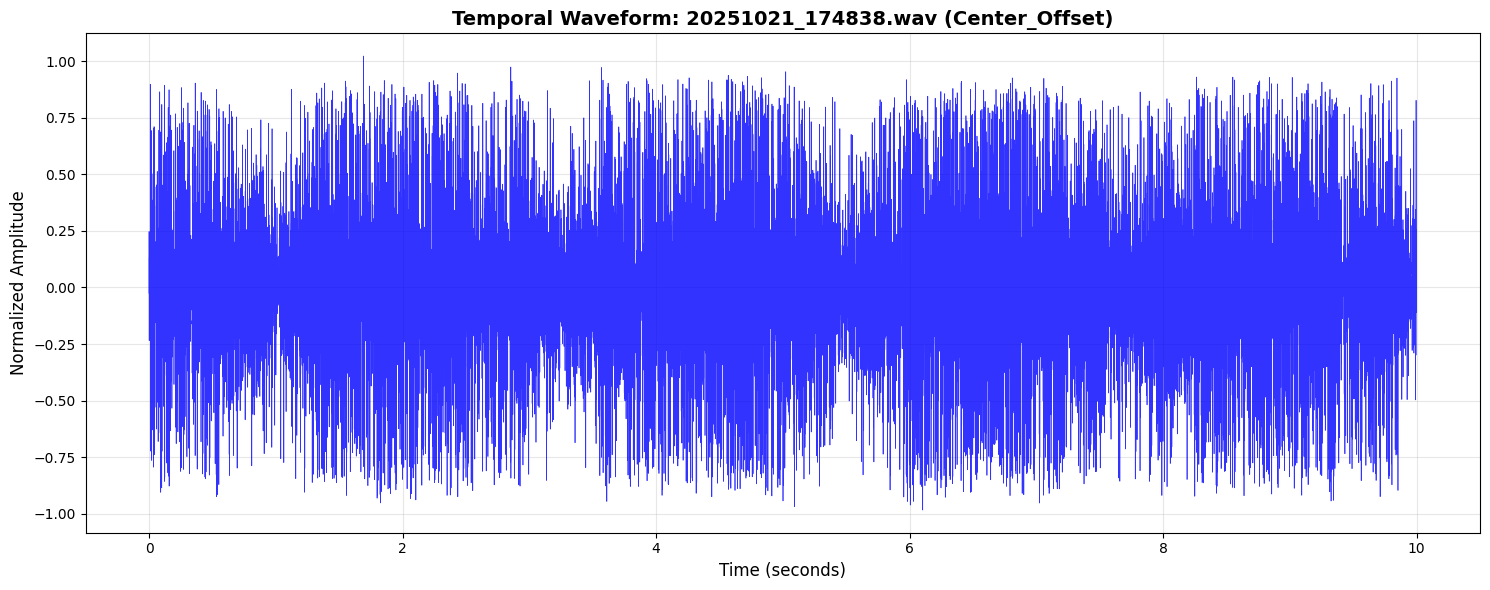

In [75]:
# Generate temporal axis
time_axis = np.linspace(0, len(audio_data[0:400000])/sample_rate, 400000)

# Temporal waveform visualization
plt.figure(figsize=(15, 6))
plt.plot(time_axis, audio_data[0:400000], linewidth=0.5, alpha=0.8, color='blue')
plt.title(f'Temporal Waveform: {sample_filename} ({sample_label})', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Normalized Amplitude', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 3.3 Time-Frequency Analysis via Spectrogram

Spectrograms reveal the temporal evolution of frequency content through Short-Time Fourier Transform (STFT). Mechanical faults typically manifest as characteristic frequency patterns that evolve over time, making time-frequency analysis essential for fault detection.

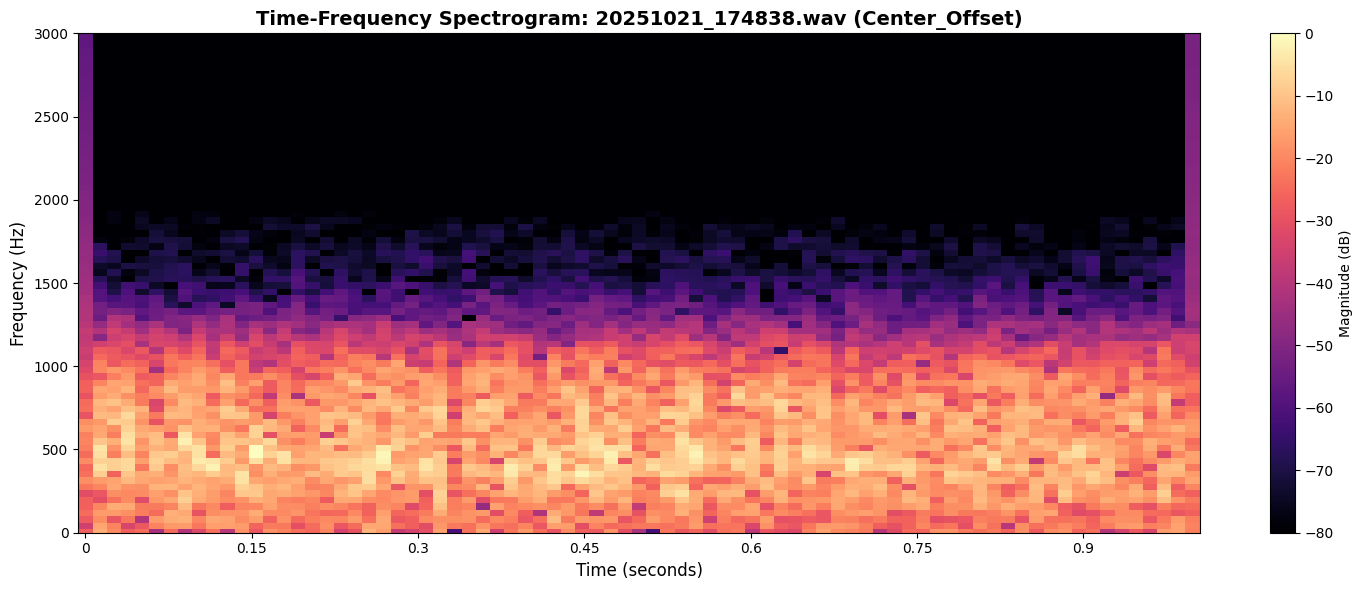

🔬 STFT: 513 freq × 79 time bins
📊 Frequency resolution: 39.1 Hz
⏱️ Time resolution: 12.8 ms


In [76]:
import librosa
import librosa.display

# STFT parameters for optimal time-frequency resolution
n_fft = 1024        # Window size: determines frequency resolution
hop_length = 512    # Frame advance: 50% overlap for smooth temporal transitions
window = 'hann'     # Hanning window for spectral leakage reduction

# Compute Short-Time Fourier Transform
stft_matrix = librosa.stft(audio_data[0:40000], n_fft=n_fft, hop_length=hop_length, window=window)
magnitude_spectrum = np.abs(stft_matrix)

# Convert to logarithmic scale for better dynamic range visualization
magnitude_db = librosa.amplitude_to_db(magnitude_spectrum, ref=np.max)

# Time-frequency visualization
plt.figure(figsize=(15, 6))
librosa.display.specshow(magnitude_db, 
                        sr=sample_rate, 
                        x_axis='time', 
                        y_axis='hz',
                        hop_length=hop_length,
                        cmap='magma')
plt.colorbar(label='Magnitude (dB)')
plt.title(f'Time-Frequency Spectrogram: {sample_filename} ({sample_label})', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Frequency (Hz)', fontsize=12)
plt.ylim(0, 3000)  # Display up to Nyquist frequency
plt.tight_layout()
plt.show()

# STFT analysis parameters
freq_resolution = sample_rate / n_fft
time_resolution = hop_length / sample_rate
num_freq_bins = magnitude_db.shape[0]
num_time_frames = magnitude_db.shape[1]

print(f"🔬 STFT: {num_freq_bins} freq × {num_time_frames} time bins")
print(f"📊 Frequency resolution: {freq_resolution:.1f} Hz")
print(f"⏱️ Time resolution: {time_resolution*1000:.1f} ms")

## 🤔 Reflection Questions & Exploration

### 💭 Think About:

1. **Signal Characteristics**: Compare the waveform patterns between different gear conditions. What differences do you notice in amplitude, frequency, or temporal patterns that might indicate mechanical faults?

2. **Diagnostic Features**: Based on the visualizations, which acoustic characteristics (amplitude variations, frequency content, temporal patterns) do you think would be most useful for distinguishing between healthy and faulty gears?

3. **Frequency Filtering Impact**: The audio is low-pass filtered at 1000 Hz. How might this affect fault detection? What information might be lost or preserved by limiting the frequency range?

### 🔬 Things to Try:

- **Compare Across Classes**: Load samples from different fault types (e.g., `Chipped_Tooth`, `Vertical_Wear`, `Good`) and compare their waveforms and spectrograms side-by-side
- **Audio Playback**: Listen to different fault types - can you hear the differences that the visualizations reveal?
- **Adjust Cutoff Frequency**: Try modifying `lowpass_cutoff` (currently 1000 Hz) to see how different frequency ranges affect the signal characteristics and fault detection capability

---
## 🧠 Step 4: Feature Engineering

Feature engineering transforms raw signals into compact, informative representations suitable for machine learning algorithms. For acoustic signals, this is critical because raw audio contains 10³-10⁵ samples per second, creating computational intractability.o contains 10³-10⁵ samples per second, creating computational intractability.

### 4.1 Hierarchical Feature Extraction Architecture

This workshop implements a four-tier feature hierarchy with increasing computational complexity:

#### 🟢 **RAW Features** (~10,000 dimensions)
Temporal downsampling via uniform binning. Preserves waveform morphology for deep learning architectures with minimal transformation. waveform morphology for deep learning architectures with minimal transformation.

#### 🔵 **BASIC Features** (~15 dimensions)
First and second-order temporal statistics: mean, variance, skewness, kurtosis, energy, zero-crossing rate. Computationally efficient baseline features.First and second-order temporal statistics: mean, variance, skewness, kurtosis, energy, zero-crossing rate. Computationally efficient baseline features.

#### 🟡 **STANDARD Features** (~80 dimensions) ⭐ **RECOMMENDED***
Comprehensive time-frequency analysis including:
- **Temporal**: Statistical descriptors, energy distribution
- **Spectral**: MFCCs, centroid, bandwidth, rolloff, flatness, contrasts, contrast
- **Harmonic**: Chroma features, tonal characteristics

Optimal balance of performance and computational efficiency for industrial deployment. efficiency for industrial deployment.

#### 🔴 **ADVANCED Features** (~100 dimensions)
Nonlinear dynamics and information theory: Hjorth parameters, sample entropy, permutation entropy, spectral entropy. Maximum discriminative power for complex fault patterns. parameters, sample entropy, permutation entropy, spectral entropy. Maximum discriminative power for complex fault patterns.



### 4.2 Feature Extraction Demo

This section demonstrates feature extraction across complexity levels using a representative 5-second audio segment. The analysis reveals the information content and computational characteristics of each feature tier.

🎬 Analysis: 10.0s-11.0s (40,000 samples)


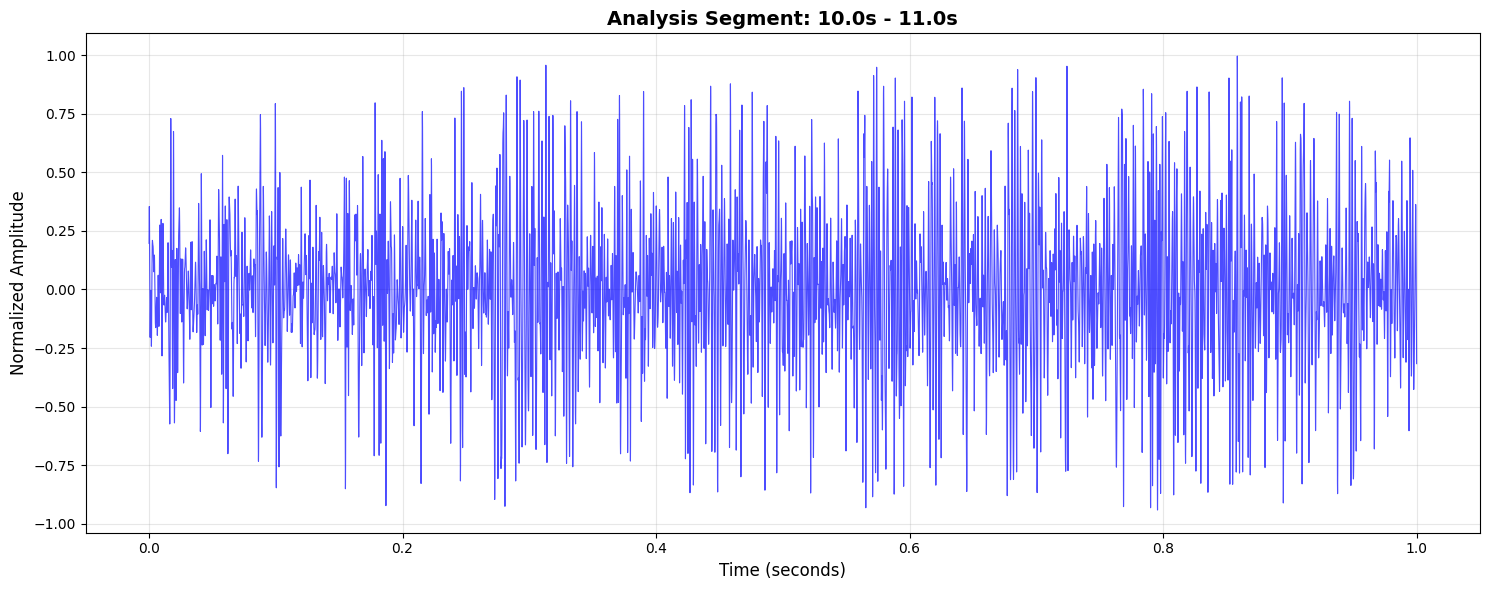

📊 Peak: 0.996, RMS: 0.315, Energy: 3969


In [77]:
# Extract representative analysis segment
segment_start = 10.0  # Analysis window start time (seconds)
segment_duration = 1.0  # Analysis window duration (seconds)

# Calculate sample boundaries
start_sample = int(segment_start * sample_rate)
end_sample = int((segment_start + segment_duration) * sample_rate)

# Extract temporal segment
demo_segment = audio_data[start_sample:end_sample]
demo_time = np.linspace(0, segment_duration, len(demo_segment))

print(f"🎬 Analysis: {segment_start}s-{segment_start + segment_duration}s ({len(demo_segment):,} samples)")
display(Audio(data=demo_segment, rate=sample_rate))

# Temporal visualization of analysis segment
plt.figure(figsize=(15, 6))
plt.plot(demo_time, demo_segment, linewidth=0.8, color='blue', alpha=0.7)
plt.title(f'Analysis Segment: {segment_start}s - {segment_start + segment_duration}s', 
          fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Normalized Amplitude', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Segment statistical characterization
peak_amplitude = np.max(np.abs(demo_segment))
rms_value = np.sqrt(np.mean(demo_segment**2))
total_energy = np.sum(demo_segment**2)

print(f"📊 Peak: {peak_amplitude:.3f}, RMS: {rms_value:.3f}, Energy: {total_energy:.0f}")

### 🟢 RAW Features: Temporal Binning Analysis

RAW features implement temporal downsampling through uniform binning, reducing dimensionality while preserving essential waveform characteristics. This approach maintains temporal structure necessary for deep learning architectures.

🟢 RAW: 40,000 → 1,000 features (40:1 compression)


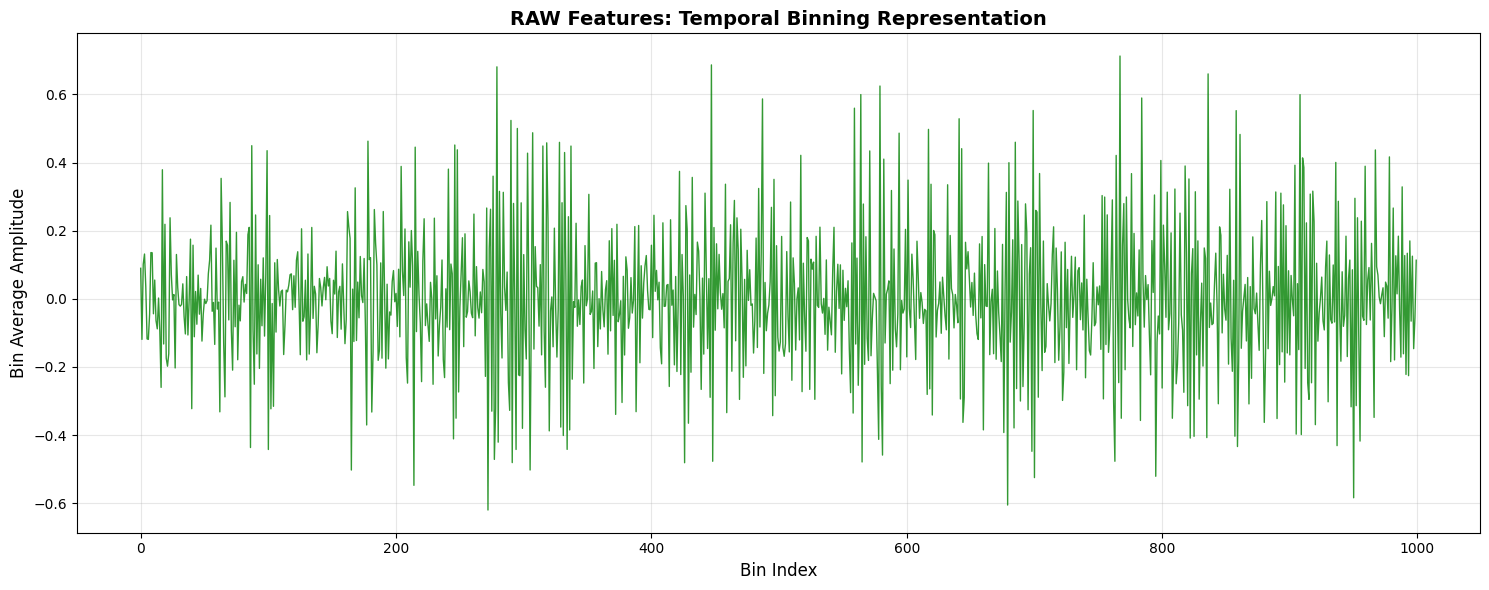

📊 Range: [-0.620, 0.713], Mean: 0.002


In [78]:
# RAW features: Temporal binning implementation
from rich_features import extract_features_for_list

# Configure binning parameters
n_raw_features = 1000  # Target feature dimensionality
samples_per_bin = len(demo_segment) // n_raw_features

# Implement uniform temporal binning
raw_features = []
for i in range(n_raw_features):
    start_idx = i * samples_per_bin
    end_idx = min((i + 1) * samples_per_bin, len(demo_segment))
    
    if start_idx < len(demo_segment):
        # Average samples within each bin
        bin_average = np.mean(demo_segment[start_idx:end_idx])
        raw_features.append(bin_average)
    else:
        raw_features.append(0.0)

raw_features = np.array(raw_features)

# Dimensionality reduction analysis
original_samples = len(demo_segment)
compressed_features = len(raw_features)
compression_ratio = original_samples / compressed_features

print(f"🟢 RAW: {original_samples:,} → {compressed_features:,} features ({compression_ratio:.0f}:1 compression)")

# Visualization of binned features
plt.figure(figsize=(15, 6))
plt.plot(raw_features, linewidth=1.0, color='green', alpha=0.8)
plt.title('RAW Features: Temporal Binning Representation', fontsize=14, fontweight='bold')
plt.xlabel('Bin Index', fontsize=12)
plt.ylabel('Bin Average Amplitude', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistical characterization
feature_min = np.min(raw_features)
feature_max = np.max(raw_features)
feature_mean = np.mean(raw_features)
feature_std = np.std(raw_features)

print(f"📊 Range: [{feature_min:.3f}, {feature_max:.3f}], Mean: {feature_mean:.3f}")

### 🔵 BASIC Features: Statistical Signal Characterization

BASIC features extract fundamental statistical descriptors from the temporal domain, providing computationally efficient signal characterization for rapid analysis and baseline model performance.

🔵 BASIC: 14 temporal statistical features extracted


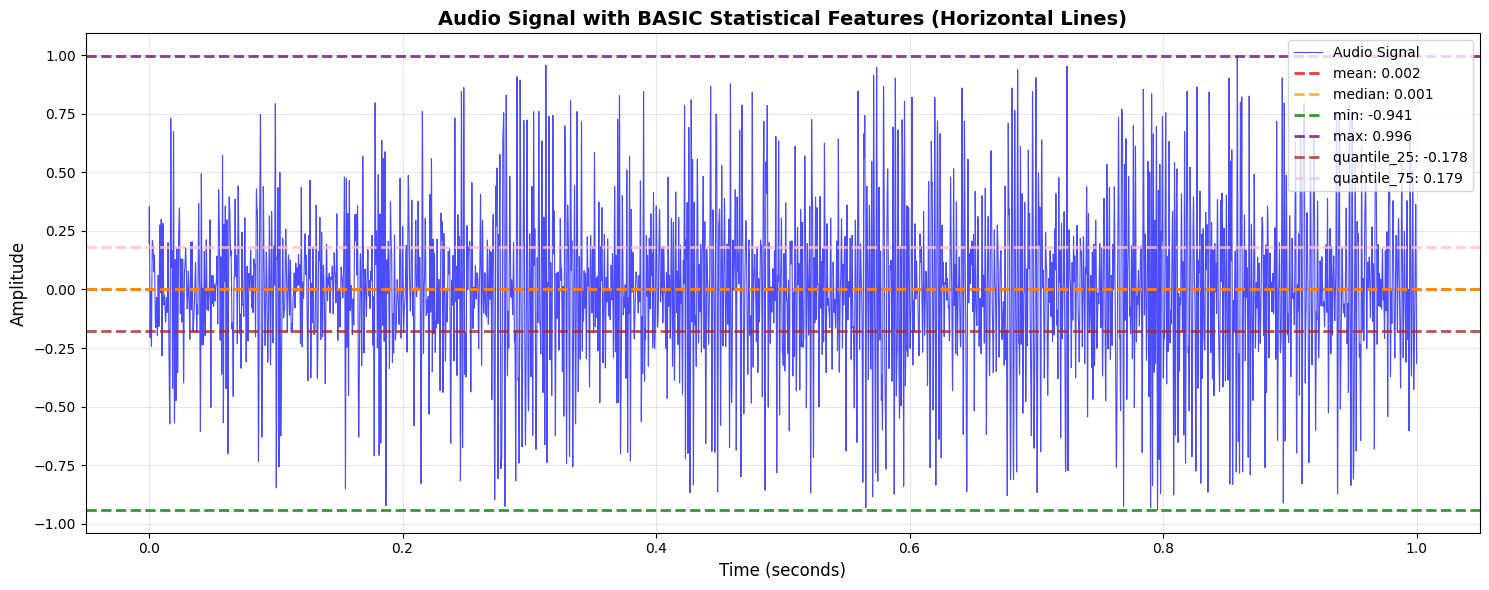

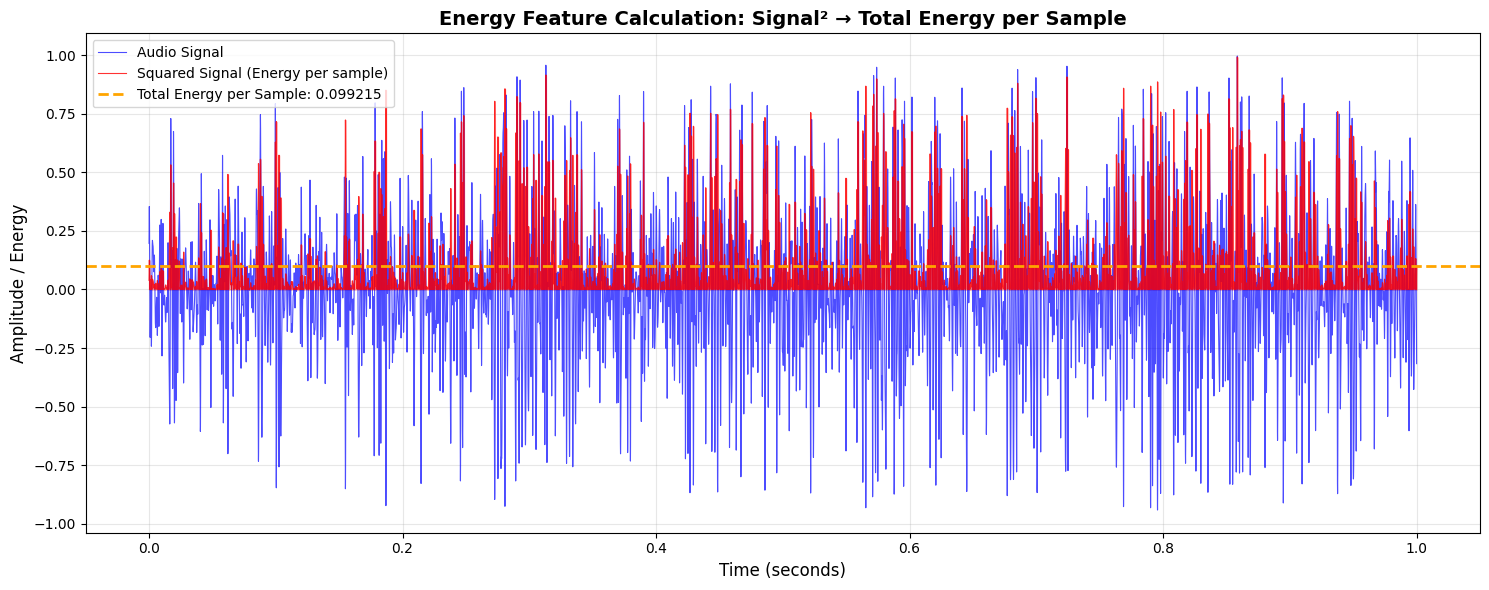

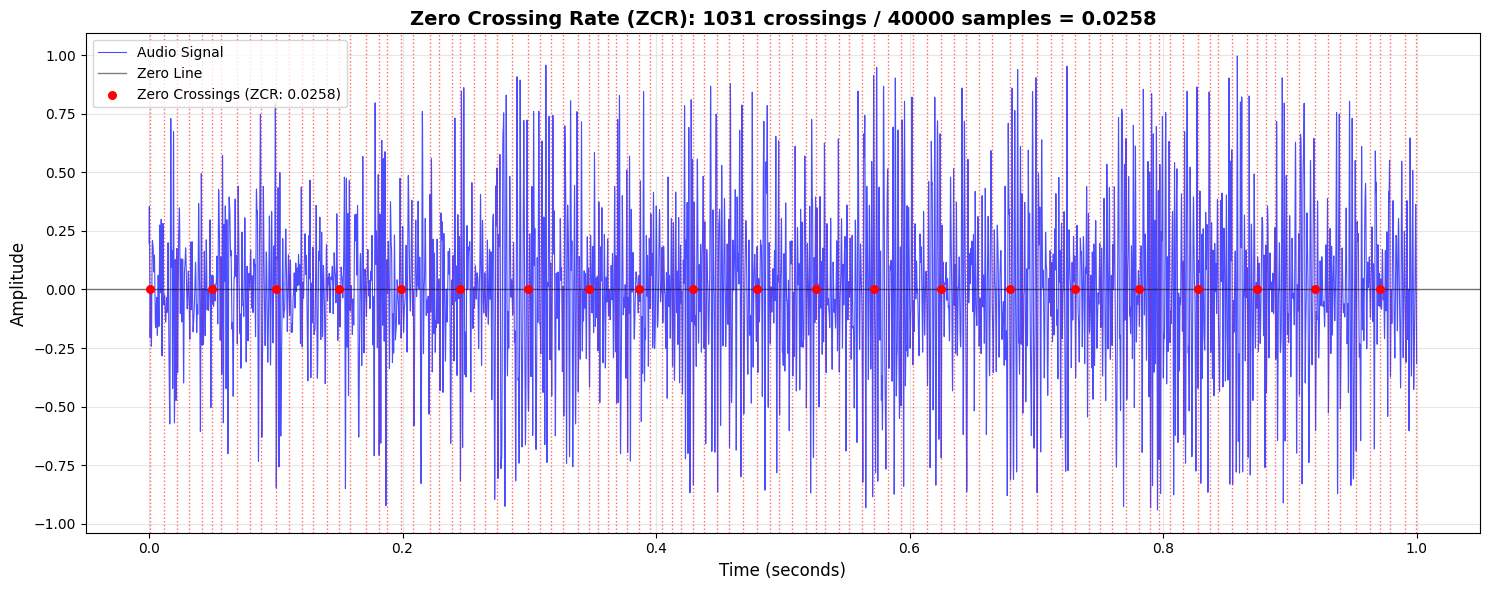

In [ ]:
# 🔵 BASIC features: Temporal statistical analysis
from rich_features import extract_basic_features

# Extract temporal statistical descriptors
basic_features, basic_names = extract_basic_features(demo_segment, sample_rate)

print(f"🔵 BASIC: {len(basic_features)} temporal statistical features extracted")

# Create visualization with waveform and statistical features as horizontal lines
plt.figure(figsize=(15, 6))

# Generate time axis for the demo segment
demo_time = np.linspace(0, len(demo_segment)/sample_rate, len(demo_segment))

# Plot waveform with statistical features as horizontal lines
plt.plot(demo_time, demo_segment, linewidth=0.8, color='blue', alpha=0.7, label='Audio Signal')
plt.title('Audio Signal with BASIC Statistical Features (Horizontal Lines)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid(True, alpha=0.3)

# Add horizontal lines for key statistical features
colors = ['red', 'orange', 'green', 'purple', 'brown', 'pink']

# Plot most interpretable features as horizontal lines
key_features = ['mean', 'median', 'min', 'max', 'quantile_25', 'quantile_75']
for i, feature_name in enumerate(key_features):
    if feature_name in basic_names:
        idx = basic_names.index(feature_name)
        feature_value = basic_features[idx]
        color = colors[i % len(colors)]
        
        plt.axhline(y=feature_value, color=color, linestyle='--', linewidth=2, 
                   alpha=0.8, label=f'{feature_name}: {feature_value:.3f}')

plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


# Plot 1: Total Energy per Sample calculation visualization
plt.figure(figsize=(15, 6))
plt.plot(demo_time, demo_segment, linewidth=0.8, color='blue', alpha=0.7, label='Audio Signal')
plt.plot(demo_time, demo_segment**2, linewidth=0.8, color='red', alpha=0.8, label='Squared Signal (Energy per sample)')
plt.axhline(y=total_energy/len(demo_segment), color='orange', linestyle='--', linewidth=2, 
           label=f'Total Energy per Sample: {total_energy/len(demo_segment):.6f}')
plt.fill_between(demo_time, demo_segment**2, alpha=0.3, color='red')
plt.title('Energy Feature Calculation: Signal² → Total Energy per Sample', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Amplitude / Energy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# Plot 2: Zero Crossing Rate calculation visualization
plt.figure(figsize=(15, 6))

# Calculate zero crossings for visualization - detect when signal crosses from positive to negative (or vice versa)
# Zero crossing occurs when the sign changes between adjacent samples
zero_crossings = []                                           # List to store indices where zero crossings occur
for i in range(1, len(demo_segment)):                        # Check each sample against the previous one
    if (demo_segment[i-1] >= 0) != (demo_segment[i] >= 0):   # If signs are different (one positive, one negative)
        zero_crossings.append(i)                             # Record this index as a zero crossing

zero_crossings = np.array(zero_crossings)            # Convert to numpy array for easier manipulation
zcr_value = len(zero_crossings) / len(demo_segment)  # Zero Crossing Rate = total crossings / total samples

plt.plot(demo_time, demo_segment, linewidth=0.8, color='blue', alpha=0.7, label='Audio Signal')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Zero Line')

# Mark zero crossings (show every 10th crossing to avoid clutter)
if len(zero_crossings) > 0:
    for crossing in zero_crossings[::10]:
        plt.axvline(x=demo_time[crossing], color='red', linestyle=':', alpha=0.6, linewidth=1)
    
    plt.scatter(demo_time[zero_crossings[::50]], np.zeros(len(zero_crossings[::50])), 
               color='red', s=30, zorder=5, label=f'Zero Crossings (ZCR: {zcr_value:.4f})')

plt.title(f'Zero Crossing Rate (ZCR): {len(zero_crossings)} crossings / {len(demo_segment)} samples = {zcr_value:.4f}', 
         fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 🟡 STANDARD Features: Multimodal Signal Analysis ⭐ **RECOMMENDED**

STANDARD features integrate temporal and spectral analysis techniques, providing comprehensive signal characterization through time-frequency decomposition, cepstral analysis, and perceptually-motivated transformations.

🟡 STANDARD Features Analysis:
   Number of features: 60
   Feature types: Time-domain + Frequency-domain + MFCCs
   Computation time: Moderate (~10-50ms)


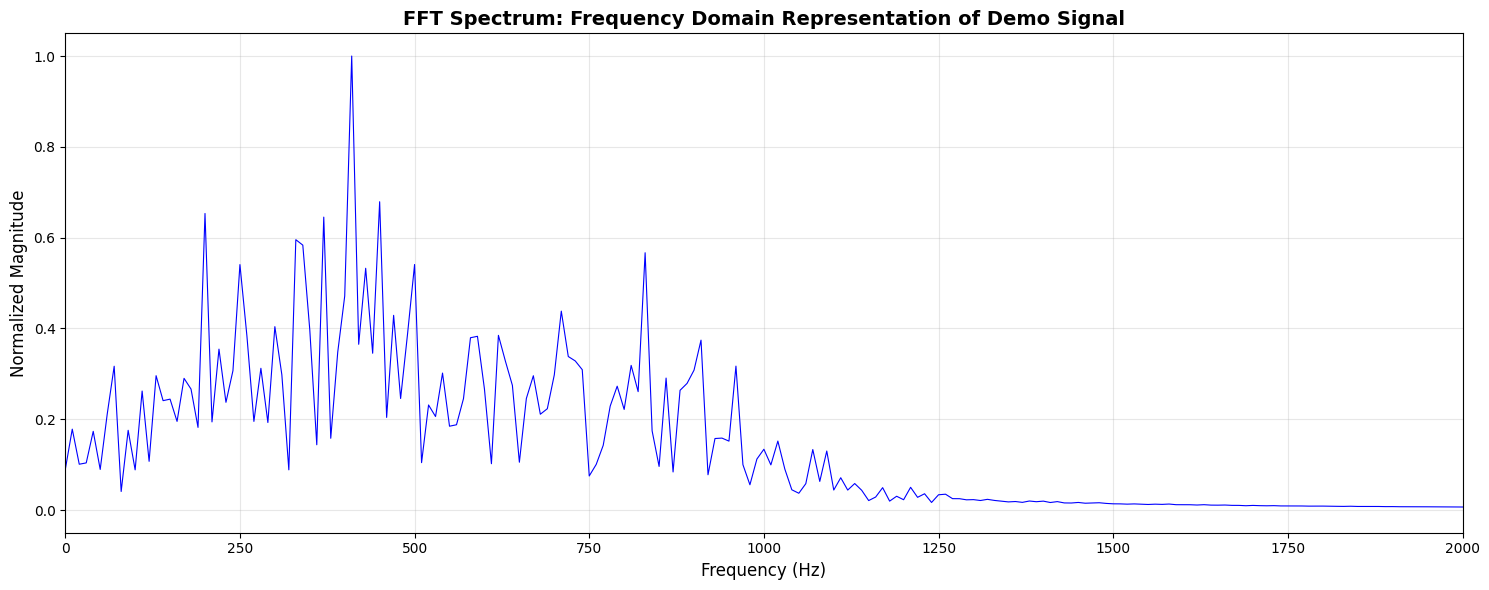

📊 FFT Analysis:
   Total frequency bins: 2000
   Frequency resolution: 10.0 Hz
   Maximum frequency: 19990 Hz


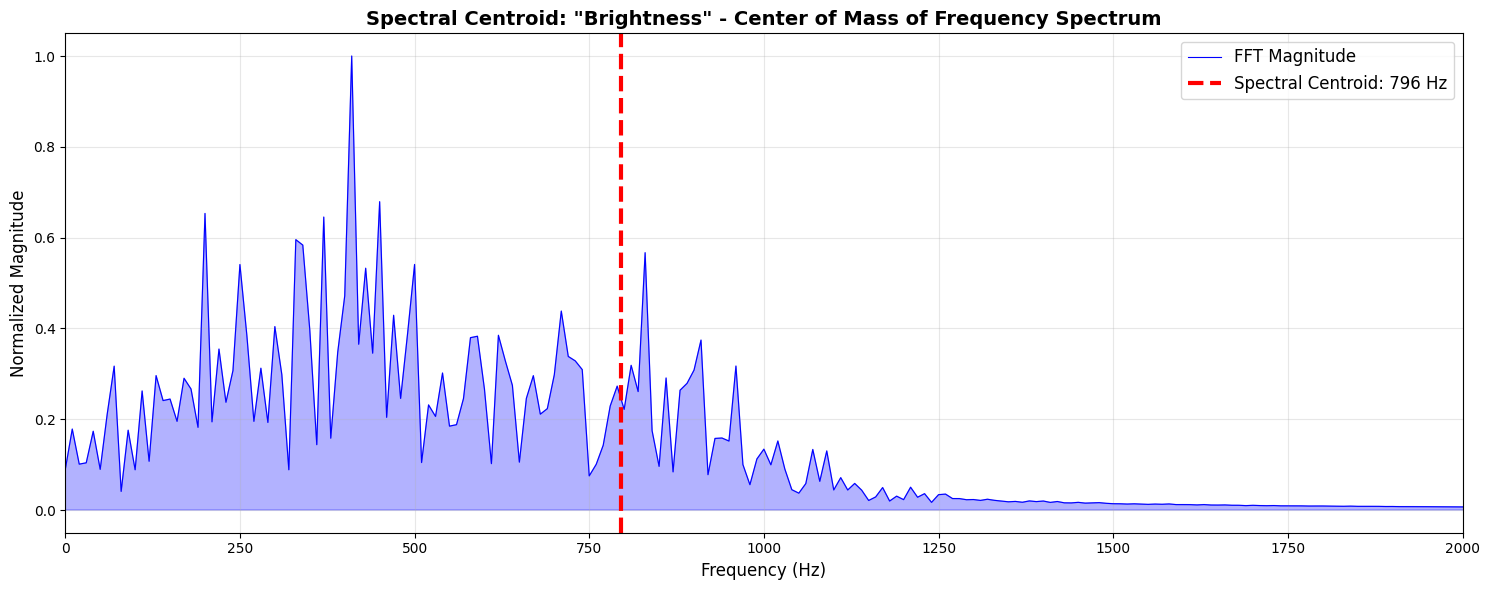

🌟 Spectral Centroid = 796 Hz
   • Higher values = 'Brighter' sound (more high-frequency content)
   • Lower values = 'Darker' sound (more low-frequency content)


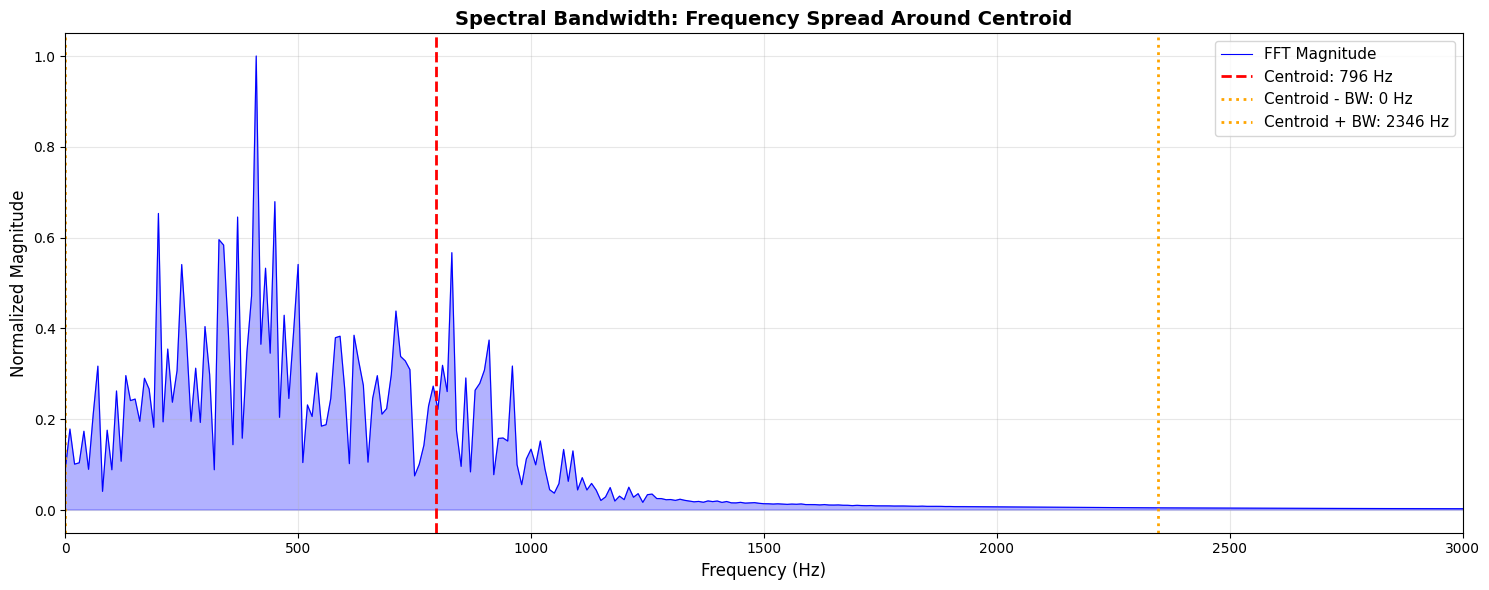

📏 Spectral Bandwidth = 1550 Hz
   • Higher values = More spread out frequencies (noisy/broadband)
   • Lower values = More concentrated frequencies (tonal/narrowband)


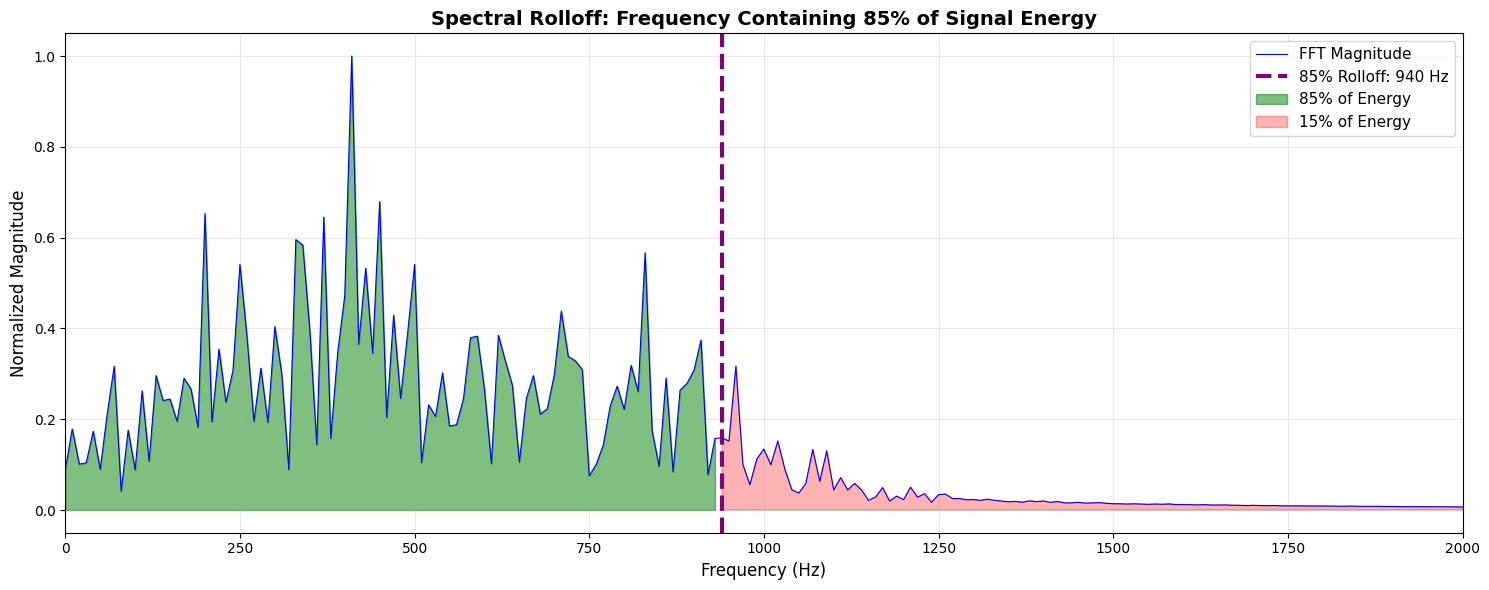

🎯 Spectral Rolloff = 940 Hz
   • Higher values = More high-frequency content
   • Lower values = Energy concentrated in low frequencies


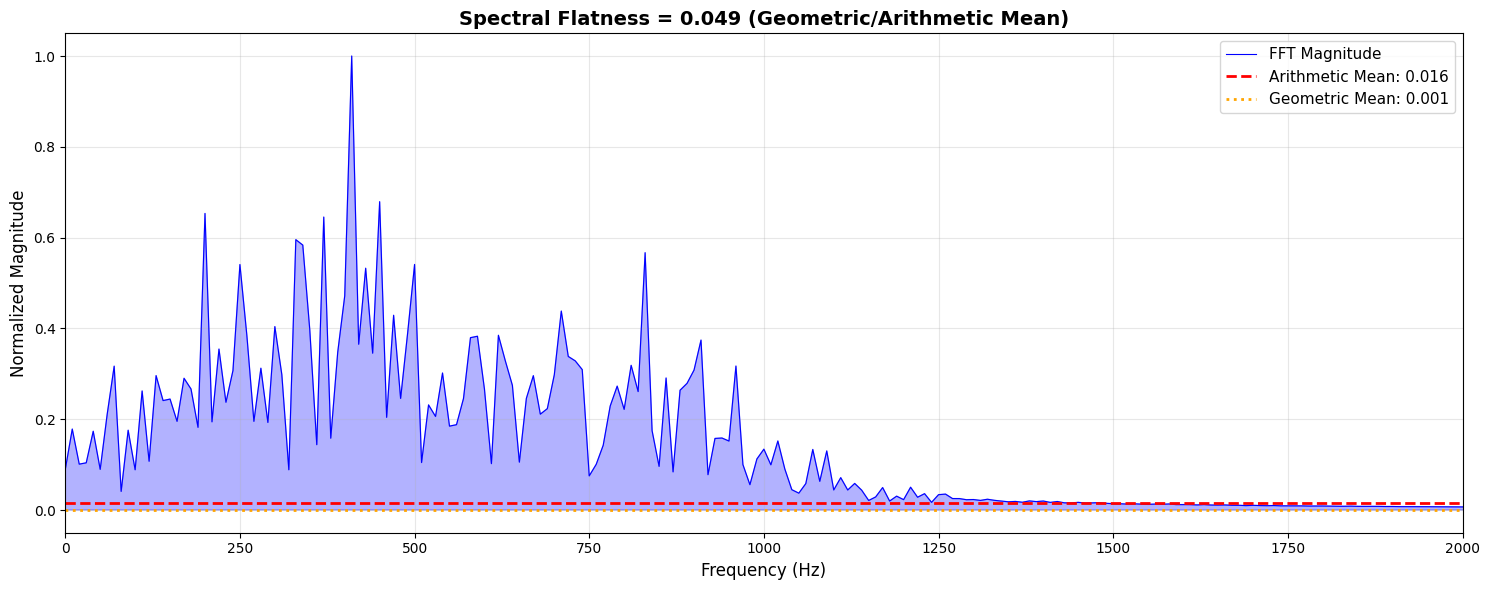

🎵 Spectral Flatness = 0.049
   • Values near 1.0 = 'Noisy' (white noise-like, flat spectrum)
   • Values near 0.0 = 'Tonal' (pitched sounds, peaky spectrum)


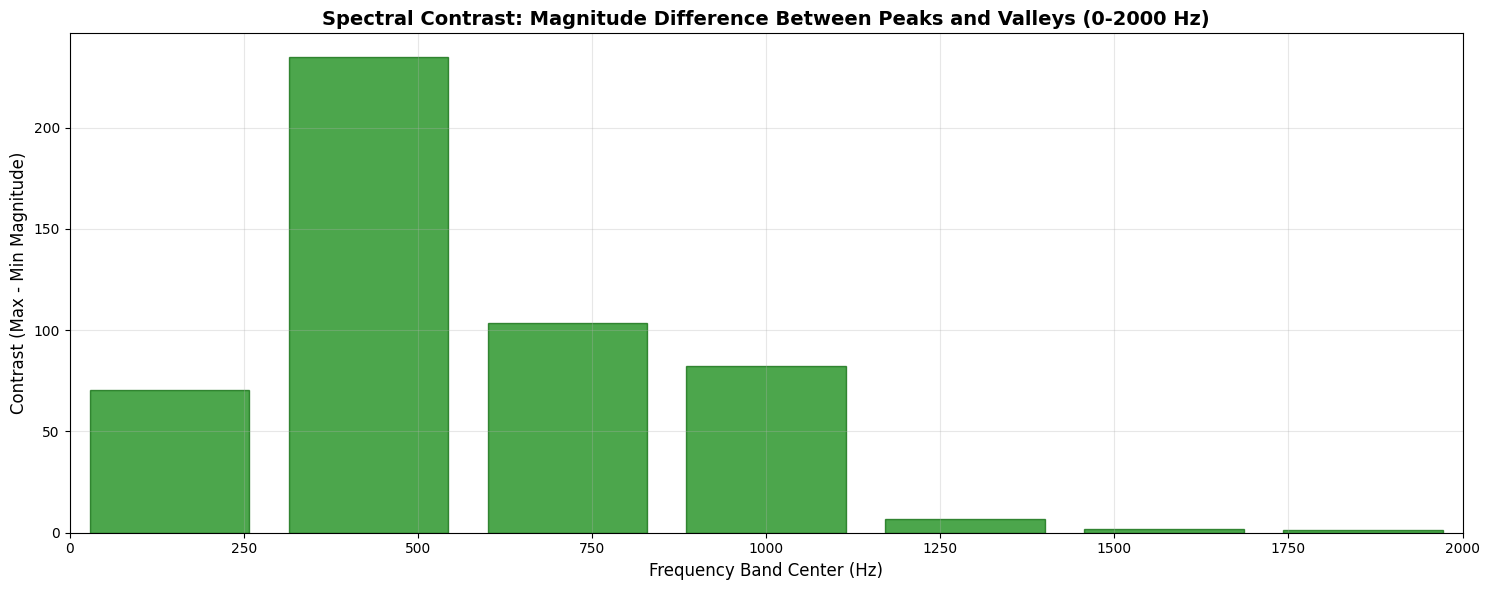

🏔️ Spectral Contrast (mean across bands, 0-2000 Hz): 71.6
   • Higher values = Clear distinction between peaks and valleys
   • Lower values = Flatter, more uniform frequency distribution
   • Frequency range analyzed: 0-2000 Hz


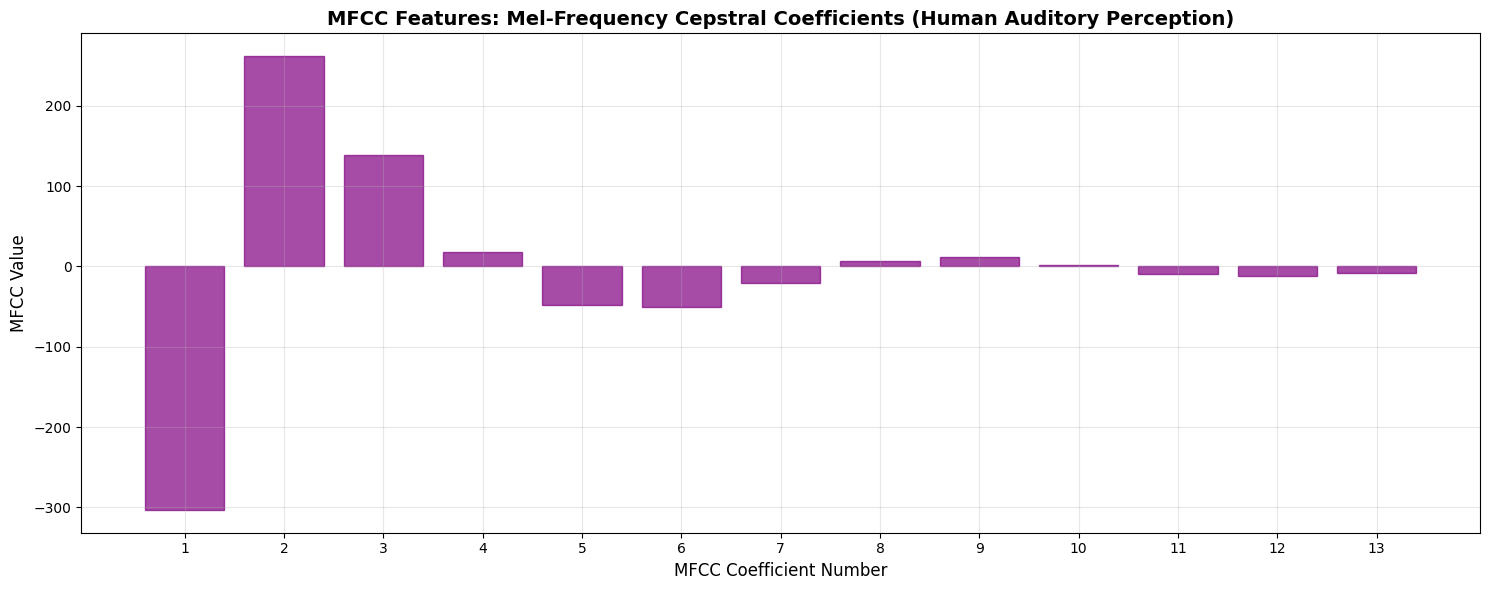

🧠 MFCC Features (13 coefficients):
   • MFCC 1-3: Overall spectral shape (most important)
   • MFCC 4-8: Mid-level spectral details
   • MFCC 9-13: Fine spectral details
   • Based on mel-scale: mimics human ear's frequency perception
   • Widely used in audio classification and speech recognition


In [ ]:
# 🟡 STANDARD Features: Deep Dive into Spectral Analysis
from rich_features import extract_standard_features
import scipy.signal
import librosa

# Extract standard features from our demo segment
standard_features, standard_names = extract_standard_features(demo_segment[0:4000], sample_rate)

print(f"🟡 STANDARD Features Analysis:")
print(f"   Number of features: {len(standard_features)}")
print(f"   Feature types: Time-domain + Frequency-domain + MFCCs")
print(f"   Computation time: Moderate (~10-50ms)")

#Apply Hanning window
window=np.hanning(len(demo_segment[0:4000]))
demo_segment_win=demo_segment[0:4000]*window

# 🔬 FUNDAMENTAL SPECTRAL ANALYSIS

# 1️⃣ Compute FFT (Frequency Domain Representation) - transform time signal to frequency components
fft_values = np.fft.fft(demo_segment_win)                              # Fast Fourier Transform: time → frequency domain
fft_magnitude = np.abs(fft_values)                                     # Get magnitude (ignore phase information)
fft_freqs = np.fft.fftfreq(len(demo_segment_win), 1/sample_rate)      # Generate frequency bins corresponding to FFT output

# Only keep positive frequencies (first half) - FFT output is symmetric, so we only need positive frequencies
n_samples = len(demo_segment_win)                    # Total number of samples in our analysis window
positive_freqs = fft_freqs[:n_samples//2]           # Keep first half of frequency bins (positive frequencies only)
positive_magnitude = fft_magnitude[:n_samples//2]   # Keep corresponding magnitude values for positive frequencies

# Normalize magnitude for better visualization - scale to 0-1 range for consistent plotting
normalized_magnitude = positive_magnitude / np.max(positive_magnitude)  # Divide by maximum to normalize

# Plot FFT Spectrum
plt.figure(figsize=(15, 6))
plt.plot(positive_freqs, normalized_magnitude, color='blue', linewidth=0.8)
plt.axvline(x=15, color='red', linestyle='--', linewidth=3, 
           label='GMF Frequency of 15Hz')
plt.title('FFT Spectrum: Frequency Domain Representation of Demo Signal', 
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Normalized Magnitude', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 2000)  # Focus on audible range
plt.tight_layout()
plt.show()

print(f"📊 FFT Analysis:")
print(f"   Total frequency bins: {len(positive_freqs)}")
print(f"   Frequency resolution: {positive_freqs[1] - positive_freqs[0]:.1f} Hz")
print(f"   Maximum frequency: {positive_freqs[-1]:.0f} Hz")
print('GMF Frequency of 15Hz')

# 2️⃣ SPECTRAL CENTROID - "Brightness" of Sound - measures where the "center of mass" of frequencies is located
# Centroid = weighted average of frequencies (center of mass of spectrum)
spectral_centroid = np.sum(positive_freqs * positive_magnitude) / np.sum(positive_magnitude)  # Σ(freq × magnitude) / Σ(magnitude)

plt.figure(figsize=(15, 6))
plt.plot(positive_freqs, normalized_magnitude, color='blue', linewidth=0.8, label='FFT Magnitude')
plt.axvline(x=spectral_centroid, color='red', linestyle='--', linewidth=3, 
           label=f'Spectral Centroid: {spectral_centroid:.0f} Hz')
plt.fill_between(positive_freqs, normalized_magnitude, alpha=0.3, color='blue')
plt.title('Spectral Centroid: "Brightness" - Center of Mass of Frequency Spectrum', 
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Normalized Magnitude', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

print(f"🌟 Spectral Centroid = {spectral_centroid:.0f} Hz")
print(f"   • Higher values = 'Brighter' sound (more high-frequency content)")
print(f"   • Lower values = 'Darker' sound (more low-frequency content)")

# 3️⃣ SPECTRAL BANDWIDTH - Spread of frequencies around centroid
# Bandwidth = weighted standard deviation of frequencies around centroid
spectral_variance = np.sum(((positive_freqs - spectral_centroid) ** 2) * positive_magnitude) / np.sum(positive_magnitude)
spectral_bandwidth = np.sqrt(spectral_variance)

plt.figure(figsize=(15, 6))
plt.plot(positive_freqs, normalized_magnitude, color='blue', linewidth=0.8, label='FFT Magnitude')
plt.axvline(x=spectral_centroid, color='red', linestyle='--', linewidth=2, 
           label=f'Centroid: {spectral_centroid:.0f} Hz')

# Only plot lower bound if it's positive
lower_bound = max(0, spectral_centroid - spectral_bandwidth)
plt.axvline(x=lower_bound, color='orange', linestyle=':', linewidth=2,
           label=f'Centroid - BW: {lower_bound:.0f} Hz')
plt.axvline(x=spectral_centroid + spectral_bandwidth, color='orange', linestyle=':', linewidth=2,
           label=f'Centroid + BW: {spectral_centroid + spectral_bandwidth:.0f} Hz')

plt.fill_between(positive_freqs, normalized_magnitude, alpha=0.3, color='blue')
plt.title('Spectral Bandwidth: Frequency Spread Around Centroid', 
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Normalized Magnitude', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 3000)
plt.tight_layout()
plt.show()

print(f"📏 Spectral Bandwidth = {spectral_bandwidth:.0f} Hz")
print(f"   • Higher values = More spread out frequencies (noisy/broadband)")
print(f"   • Lower values = More concentrated frequencies (tonal/narrowband)")

# 4️⃣ SPECTRAL ROLLOFF - Frequency below which 85% of energy is contained
cumulative_energy = np.cumsum(positive_magnitude)
total_energy = cumulative_energy[-1]
rolloff_threshold = 0.85 * total_energy
rolloff_idx = np.where(cumulative_energy >= rolloff_threshold)[0][0]
spectral_rolloff = positive_freqs[rolloff_idx]

plt.figure(figsize=(15, 6))
plt.plot(positive_freqs, normalized_magnitude, color='blue', linewidth=0.8, label='FFT Magnitude')
plt.axvline(x=spectral_rolloff, color='purple', linestyle='--', linewidth=3,
           label=f'85% Rolloff: {spectral_rolloff:.0f} Hz')
plt.fill_between(positive_freqs[:rolloff_idx], normalized_magnitude[:rolloff_idx], 
                alpha=0.5, color='green', label='85% of Energy')
plt.fill_between(positive_freqs[rolloff_idx:], normalized_magnitude[rolloff_idx:], 
                alpha=0.3, color='red', label='15% of Energy')
plt.title('Spectral Rolloff: Frequency Containing 85% of Signal Energy', 
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Normalized Magnitude', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

print(f"🎯 Spectral Rolloff = {spectral_rolloff:.0f} Hz")
print(f"   • Higher values = More high-frequency content")
print(f"   • Lower values = Energy concentrated in low frequencies")

# 5️⃣ SPECTRAL FLATNESS - How "white noise"-like vs "tonal" the signal is
# Flatness = geometric mean / arithmetic mean of magnitude spectrum
geometric_mean = np.exp(np.mean(np.log(positive_magnitude + 1e-10)))  # Add small value to avoid log(0)
arithmetic_mean = np.mean(positive_magnitude)
spectral_flatness = geometric_mean / arithmetic_mean

plt.figure(figsize=(15, 6))
plt.plot(positive_freqs, normalized_magnitude, color='blue', linewidth=0.8, label='FFT Magnitude')
plt.axhline(y=arithmetic_mean/np.max(positive_magnitude), color='red', linestyle='--', linewidth=2,
           label=f'Arithmetic Mean: {arithmetic_mean/np.max(positive_magnitude):.3f}')
plt.axhline(y=geometric_mean/np.max(positive_magnitude), color='orange', linestyle=':', linewidth=2,
           label=f'Geometric Mean: {geometric_mean/np.max(positive_magnitude):.3f}')
plt.fill_between(positive_freqs, normalized_magnitude, alpha=0.3, color='blue')
plt.title(f'Spectral Flatness = {spectral_flatness:.3f} (Geometric/Arithmetic Mean)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Normalized Magnitude', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

print(f"🎵 Spectral Flatness = {spectral_flatness:.3f}")
print(f"   • Values near 1.0 = 'Noisy' (white noise-like, flat spectrum)")
print(f"   • Values near 0.0 = 'Tonal' (pitched sounds, peaky spectrum)")

# 6️⃣ SPECTRAL CONTRAST - Energy difference between peaks and valleys
# Using magnitude difference instead of librosa spectral contrast
S = np.abs(librosa.stft(demo_segment_win.astype(float), hop_length=512))

# Calculate spectral contrast as difference between max and min in each frequency band
# Divide spectrum into frequency bands - focus on 0-5000 Hz range
n_bands = 7

# Convert frequency range to bin indices
# STFT frequency resolution: sr / n_fft
n_fft = 2048  # default for librosa.stft
freq_resolution = sample_rate / n_fft
max_freq = 2000
max_bin = int(max_freq / freq_resolution)

# Only use bins up to 5000 Hz
S_limited = S[:max_bin, :]

# Divide the limited frequency range into bands
freq_band_edges = np.linspace(0, S_limited.shape[0], n_bands + 1, dtype=int)

# Calculate contrast for each band
delta_mag = []
for i in range(n_bands):
    band_start = freq_band_edges[i]
    band_end = freq_band_edges[i + 1]
    S_band = S_limited[band_start:band_end, :]
    
    # Contrast = max - min magnitude in this band
    contrast_value = S_band.max() - S_band.min()
    delta_mag.append(contrast_value)

delta_mag = np.array(delta_mag)

plt.figure(figsize=(15, 6))
# Create frequency bands for contrast visualization - 0-5000 Hz
band_freqs = np.linspace(0, max_freq, n_bands+1)
band_centers = (band_freqs[:-1] + band_freqs[1:]) / 2

# Calculate proper bar width to avoid overlap (use 80% of the spacing between centers)
if len(band_centers) > 1:
    bar_width = (band_centers[1] - band_centers[0]) * 0.8
else:
    bar_width = band_centers[0] * 0.1  # fallback for single band

plt.bar(band_centers, delta_mag, width=bar_width, 
        alpha=0.7, color='green', edgecolor='darkgreen')
plt.title(f'Spectral Contrast: Magnitude Difference Between Peaks and Valleys (0-{max_freq} Hz)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency Band Center (Hz)', fontsize=12)
plt.ylabel('Contrast (Max - Min Magnitude)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, max_freq)
plt.tight_layout()
plt.show()

print(f"🏔️ Spectral Contrast (mean across bands, 0-{max_freq} Hz): {np.mean(delta_mag):.1f}")
print(f"   • Higher values = Clear distinction between peaks and valleys")
print(f"   • Lower values = Flatter, more uniform frequency distribution")
print(f"   • Frequency range analyzed: 0-{max_freq} Hz")

# 7️⃣ MFCC FEATURES - Mel-Frequency Cepstral Coefficients
# MFCCs mimic human auditory perception using mel-scale
mfccs = librosa.feature.mfcc(y=demo_segment_win.astype(float), sr=sample_rate, n_mfcc=13)
mfcc_mean = np.mean(mfccs, axis=1)

plt.figure(figsize=(15, 6))
plt.bar(range(1, len(mfcc_mean)+1), mfcc_mean, alpha=0.7, color='purple', edgecolor='purple')
plt.title('MFCC Features: Mel-Frequency Cepstral Coefficients (Human Auditory Perception)', 
          fontsize=14, fontweight='bold')
plt.xlabel('MFCC Coefficient Number', fontsize=12)
plt.ylabel('MFCC Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(mfcc_mean)+1))
plt.tight_layout()
plt.show()

print(f"🧠 MFCC Features ({len(mfcc_mean)} coefficients):")
print(f"   • MFCC 1-3: Overall spectral shape (most important)")
print(f"   • MFCC 4-8: Mid-level spectral details")
print(f"   • MFCC 9-13: Fine spectral details")
print(f"   • Based on mel-scale: mimics human ear's frequency perception")
print(f"   • Widely used in audio classification and speech recognition")





### 🤔 Reflection Questions & Exploration

#### 💭 Think About:

1. **Feature Complexity vs. Performance**: Compare the different feature levels (BASIC, STANDARD, ADVANCED). What's the trade-off between computational complexity and discriminative power? When might you choose BASIC features over STANDARD despite potentially lower accuracy?

2. **Physical Interpretation**: Looking at the STANDARD feature visualizations (spectral centroid, bandwidth, rolloff, etc.), how do these mathematical features relate to the physical properties of gear faults? For example, what might a higher spectral centroid indicate about a mechanical fault?

3. **Temporal vs. Frequency Domain**: BASIC features operate in the time domain while STANDARD features incorporate frequency analysis. Why is frequency information so critical for acoustic fault detection? What fault characteristics might be invisible in time-domain analysis alone?

#### 🔬 Things to Try:

- **Segment Duration Experiment**: Try extracting STANDARD features from different segment durations (e.g., 0.5s, 1s, 5s, 10s). How does segment length affect feature stability and computational time? What's the optimal balance for real-time monitoring vs. detection accuracy?

- **Cut-off Frequency Modification**: The current cut-off frequency of the low-pass filer is 1000Hz while we know that the Gear meshing frequency at 30RPM (GMF) is around 15Hz. Try changing the cut-off frequency to 100Hz and observe the peaks obtained for the FFT. What could be the source of the other high frequency peaks? 
**[Gear Mesh Frequencies](https://docs.google.com/spreadsheets/d/10fKmP9ngzMna9lkFQQ36nhx-jRsR4oQC/edit?usp=sharing&ouid=104732158308486153471&rtpof=true&sd=true)**

---
## 🔧 Step 5: Feature Pipeline & Data Preprocessing

Now that we understand feature engineering theory, we'll build a scalable pipeline to extract features from all audio files and prepare the data for machine learning.

### 5.1 Scalable Feature Extraction Pipeline

This section implements a production-ready feature extraction pipeline capable of processing large audio datasets with configurable segmentation, overlap strategies, and train-test partitioning for robust model development.

In [81]:
# Configure pipeline hyperparameters
segment_duration = 5.0    # Temporal window length (seconds)
overlap_ratio = 0.5       # Inter-segment overlap coefficient  
train_ratio = 0.8         # Training partition fraction
edge_buffer = 1.0         # Boundary artifact exclusion (seconds)
lowpass_cutoff = 1000.0  # Low-pass filter cutoff frequency (Hz)

print(f"🔧 Pipeline: {segment_duration}s segments, {overlap_ratio*100:.0f}% overlap, {train_ratio:.0%} train split")

🔧 Pipeline: 5.0s segments, 50% overlap, 80% train split


### Automated Dataset Processing Architecture

Implementation of a scalable processing function that applies feature extraction across multiple complexity levels, enabling systematic performance comparison of different representation strategies.

In [ ]:
def process_dataset(feature_level, data_dir=data_dir):
    
    #Process the entire audio dataset with specified feature level.
    
    print(f"🔄 Processing dataset with {feature_level.upper()} features...")
    
    # Use our orchestrator to process all files - this is the main pipeline function
    result = run_pipeline_on_dataset(
        data_dir,                                     # Directory containing audio files organized by class (folder name = class label)
        segment_seconds=segment_duration,             # Cut each audio file into segments of this duration for training
        overlap=overlap_ratio,                        # Overlap between consecutive segments (0.5 = 50% overlap increases dataset size)
        train_fraction=train_ratio,                   # Fraction of data used for training (0.8 = 80% train, 20% test)
        buffer_seconds=edge_buffer,                   # Skip this many seconds at start/end of files to avoid artifacts
        feature_level=feature_level,                  # Which feature extraction method to use ('basic', 'standard', 'advanced')
        lowpass_cutoff=lowpass_cutoff,               # Remove frequencies above this threshold to focus on gear mechanics
    )
    
    # Extract processed data from the pipeline result dictionary
    X_train = result['train']['X']                    # Training feature matrix (n_samples × n_features)
    y_train = np.array(result['train']['y'])         # Training labels (folder names converted to class labels)
    X_test = result['test']['X']                     # Test feature matrix (separate files reserved for evaluation)
    y_test = np.array(result['test']['y'])           # Test labels (ground truth for model evaluation)
    # FIX: feature_names is inside 'train' dict, not at top level
    feature_names = result['train'].get('feature_names', [])  # Names of each feature for interpretability
    
    print(f"   ✅ Train samples: {X_train.shape[0]:,} segments")     # How many audio segments for training
    print(f"   ✅ Test samples: {X_test.shape[0]:,} segments")      # How many audio segments for testing  
    print(f"   ✅ Features per segment: {X_train.shape[1]:,}")      # Number of features extracted from each segment
    print(f"   ✅ Classes: {np.unique(y_train)}")                   # Unique fault types found in the dataset
    
    return {
        'X_train': X_train, 'y_train': y_train,      # Training data ready for ML algorithms
        'X_test': X_test, 'y_test': y_test,          # Test data for unbiased performance evaluation
        'feature_names': feature_names,               # Feature descriptions for model interpretation
        'feature_level': feature_level                # Which feature extraction level was used
    }

# 🎯 Let's start with BASIC features (fast processing)
print("🚀 Starting with BASIC features for quick analysis...")
basic_data = process_dataset('basic')

# 📊 Show class distribution
print(f"\n📊 Class Distribution:")
train_counts = pd.Series(basic_data['y_train']).value_counts()
test_counts = pd.Series(basic_data['y_test']).value_counts()
print(f"   Training set: {dict(train_counts)}")
print(f"   Test set: {dict(test_counts)}")


🚀 Starting with BASIC features for quick analysis...
🔄 Processing dataset with BASIC features...
   ✅ Train samples: 376 segments
   ✅ Test samples: 44 segments
   ✅ Features per segment: 14
   ✅ Classes: ['Center_Offset' 'Chipped_Tooth' 'Good' 'Vertical_Wear']

📊 Class Distribution:
   Training set: {'Center_Offset': np.int64(94), 'Chipped_Tooth': np.int64(94), 'Good': np.int64(94), 'Vertical_Wear': np.int64(94)}
   Test set: {'Center_Offset': np.int64(11), 'Chipped_Tooth': np.int64(11), 'Good': np.int64(11), 'Vertical_Wear': np.int64(11)}


### 5.2 Feature Standardization and Train/Test Split

Feature normalization is essential for distance-based algorithms and gradient descent optimization. This section implements standardization protocols that ensure algorithmic convergence and prevent feature magnitude bias.

### 🔬 Why Feature Scaling Matters

**Scale-Sensitive Algorithms**: Neural networks, logistic regression, and KNN require uniform feature scales for optimal performance

**Mathematical Foundation**: StandardScaler applies Z-score normalization (z = (x - μ) / σ) to achieve mean ≈ 0, std ≈ 1

**Data Leakage Prevention**: Scaler must be fitted on training data only, then applied to test data using same parameters

**Label Encoding**: Converts categorical target labels to numerical format required by ML algorithms

**Performance Impact**: Proper scaling prevents feature magnitude bias and ensures faster algorithm convergence


In [ ]:
# 🔧 Import ML libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def prepare_data(data_dict):
    """
    Scale features and encode labels for ML training.
    
    Args:
        data_dict: Dictionary from process_dataset()
    
    Returns:
        Dictionary with scaled features and encoded labels
    """
    # Extract data from our processed dataset dictionary
    X_train, y_train = data_dict['X_train'], data_dict['y_train']  # Training features and labels
    X_test, y_test = data_dict['X_test'], data_dict['y_test']      # Test features and labels
    
    # 🎯 Scale features to have mean=0, std=1 (Z-score normalization)
    scaler = StandardScaler()                                      # Create scaler that computes mean and std
    X_train_scaled = scaler.fit_transform(X_train)               # Calculate mean/std from training data and apply scaling
    X_test_scaled = scaler.transform(X_test)                     # Apply same scaling parameters to test data (prevent data leakage)
    
    print(f"🔄 Features scaled: {X_train.shape[1]} features, mean≈0, std≈1")
    
    # 🏷️ Encode string labels to numbers (if needed) - ML algorithms need numeric labels
    label_encoder = LabelEncoder()                               # Create encoder to map text labels to integers
    y_train_encoded = label_encoder.fit_transform(y_train)       # Learn label mapping from training set and encode
    y_test_encoded = label_encoder.transform(y_test)            # Apply same label mapping to test set
    
    print(f"🏷️ Labels encoded: {len(label_encoder.classes_)} classes")
    
    return {
        'X_train': X_train_scaled,
        'y_train': y_train_encoded,
        'X_test': X_test_scaled, 
        'y_test': y_test_encoded,
        'scaler': scaler,
        'label_encoder': label_encoder,
        'feature_names': data_dict['feature_names'],
        'feature_level': data_dict['feature_level']
    }

# 🎯 Prepare BASIC features data
basic_prepared = prepare_data(basic_data)

print(f"\\n✅ Data preparation complete!")
print(f"   Training samples: {basic_prepared['X_train'].shape[0]:,}")
print(f"   Features: {basic_prepared['X_train'].shape[1]:,}")
print(f"   Classes: {len(np.unique(basic_prepared['y_train']))}")

🔄 Features scaled: 14 features, mean≈0, std≈1
🏷️ Labels encoded: 4 classes
\n✅ Data preparation complete!
   Training samples: 376
   Features: 14
   Classes: 4


## 💥 Step 6: Naive Baseline - A Cautionary Tale

Before we build proper baselines, let's see what happens when we take the **worst possible approach**: using raw audio data directly with a simple model and no preprocessing. This demonstrates why proper feature engineering and data preparation are crucial!

### 🚨 Why This Will Fail Spectacularly:

- **🔥 Massive Dimensionality**: Raw audio has ~200,000+ samples per segment
- **⚠️ No Feature Engineering**: No meaningful signal processing 
- **🤖 Simple Algorithm**: Basic model can't handle complex raw data
- **❌ No Preprocessing**: No scaling or normalization
- **📊 Poor Generalization**: Overfitting to noise rather than patterns

### 🎯 Learning Goal: 
Understand why **"just throw raw data at ML"** doesn't work and appreciate the value of proper signal processing!

💥 NAIVE APPROACH: Raw Features + Simple Model
⚠️  WARNING: This is intentionally BAD - for educational purposes!
🔍 Extracting raw features using process_dataset...
🔄 Processing dataset with RAW features...
   ✅ Train samples: 376 segments
   ✅ Test samples: 44 segments
   ✅ Features per segment: 1,000
   ✅ Classes: ['Center_Offset' 'Chipped_Tooth' 'Good' 'Vertical_Wear']

📊 NAIVE APPROACH RESULTS:
   🎯 Accuracy: 0.8182 (81.8%)
   🚨 Naive accuracy: 81.8% - ACCEPTABLE

📋 Classification Report:


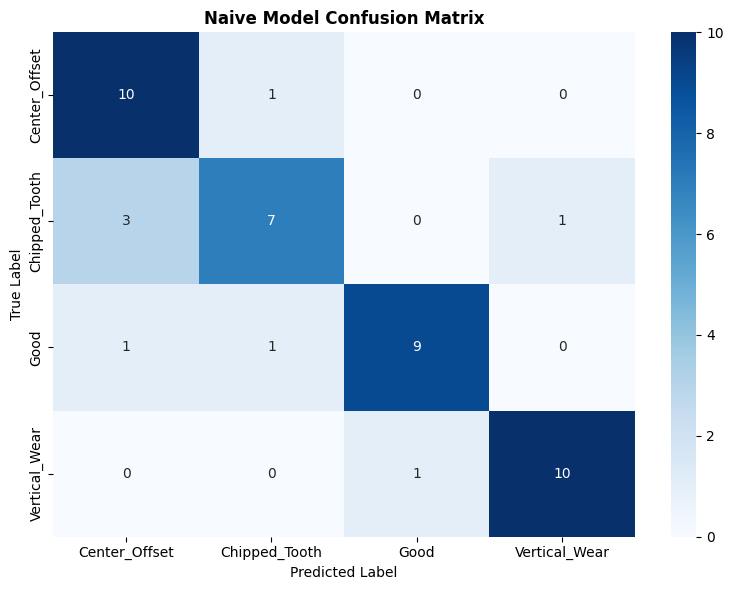

In [84]:
# 💥 Demonstrate the wrong way: Raw features + Simple model
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import time
import warnings
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("💥 NAIVE APPROACH: Raw Features + Simple Model")
print("=" * 50)
print("⚠️  WARNING: This is intentionally BAD - for educational purposes!")

# 🔥 Use process_dataset with raw feature level (minimal preprocessing)
print("🔍 Extracting raw features using process_dataset...")
raw_data = process_dataset("raw")

# Extract components from the returned dictionary
X_raw_train = raw_data['X_train']
y_raw_train = raw_data['y_train']
X_raw_test = raw_data['X_test']
y_raw_test = raw_data['y_test']
feature_names = raw_data['feature_names']
    
        
# Use default parameters (likely suboptimal)
naive_model = LogisticRegression(
    max_iter=100,     # Minimal iterations
    C=1.0,           # Default regularization
    random_state=42,
    solver='lbfgs'
)

naive_model.fit(X_raw_train, y_raw_train)

        
# Make predictions
y_pred = naive_model.predict(X_raw_test)
naive_accuracy = accuracy_score(y_raw_test, y_pred)

print(f"\n📊 NAIVE APPROACH RESULTS:")
print(f"   🎯 Accuracy: {naive_accuracy:.4f} ({naive_accuracy*100:.1f}%)")
        

# Determine performance level
if naive_accuracy < 0.6:
    performance = "POOR"
else:
    performance = "ACCEPTABLE"
    
print(f"   🚨 Naive accuracy: {naive_accuracy:.1%} - {performance}")
print(f"\n📋 Classification Report:")
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_raw_test, y_pred)
class_labels = np.unique(y_raw_test)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Naive Model Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


# Store result for comparison
naive_result = {
    'accuracy': naive_accuracy,
    'approach': 'Naive Raw Features'
}


---
## 🎯 Step 7: Proper Baseline Model

After seeing the naive approach fail, let's build a **proper baseline** using engineered features and systematic methodology. This demonstrates the value of good practices in machine learning pipeline development.

### 📚 Why This Baseline Will Work Better:
- ✅ **Engineered Features**: Using BASIC statistical features instead of raw data
- ✅ **Proper Preprocessing**: Standardized features and encoded labels
- ✅ **Reasonable Dimensionality**: ~15 features instead of 2000+ raw samples
- ✅ **Systematic Approach**: Following ML best practices

### 🎯 Comparison Goal:
Show dramatic improvement from naive → baseline → advanced approaches!

In [ ]:
# Baseline implementation: Untuned logistic regression
from sklearn.linear_model import LogisticRegression

# Configure minimal baseline model - simple linear classifier to establish performance floor
baseline_model = LogisticRegression(
    max_iter=100,          # Convergence limit (may terminate early) - low value for quick baseline
    C=1.0,                 # L2 regularization parameter (unoptimized) - controls overfitting, higher = less regularization
    solver='lbfgs',        # Limited-memory BFGS optimization - efficient for small datasets
    random_state=42        # Reproducible results across runs
)

print("🤖 Baseline model configuration:")
print("  Algorithm: Logistic regression with L2 regularization")
print("  Hyperparameters: Default values (untuned)")
print("  Feature set: Basic statistical descriptors")
print("  Optimization: Limited iterations")

# Model training on standardized features - learn decision boundaries from training data
baseline_model.fit(basic_prepared['X_train'], basic_prepared['y_train'])  # Train on scaled features and encoded labels

# Generate predictions and evaluate performance - test on unseen data to measure generalization
y_pred_baseline = baseline_model.predict(basic_prepared['X_test'])                    # Make predictions on test set
baseline_accuracy = accuracy_score(basic_prepared['y_test'], y_pred_baseline)        # Compare predictions to true labels

print(f"\n📊 Baseline performance metrics:")
print(f"  🎯 Classification accuracy: {baseline_accuracy:.4f}")
print(f"  ❌ Error rate: {1-baseline_accuracy:.4f}")

if 'naive_result' in globals():
    improvement = baseline_accuracy - naive_result['accuracy']
    print(f"   💥 Naive accuracy: {naive_result['accuracy']:.4f}")
    print(f"   ✅ Baseline accuracy: {baseline_accuracy:.4f}")
    print(f"   📊 Improvement: +{improvement:.4f} ({improvement*100:.1f} percentage points)")
    if improvement > 0:
        print(f"   🎉 That's a {((baseline_accuracy/max(naive_result['accuracy'], 0.001))-1)*100:.0f}% relative improvement!")
else:
    print(f"   🎯 Goal: Beat this {baseline_accuracy:.4f} accuracy with advanced techniques!")

print(f"\n🔥 Next Goal: Exceed baseline accuracy of {baseline_accuracy:.4f} through advanced algorithms!")

🤖 Baseline model configuration:
  Algorithm: Logistic regression with L2 regularization
  Hyperparameters: Default values (untuned)
  Feature set: Basic statistical descriptors
  Optimization: Limited iterations

📊 Baseline performance metrics:
  🎯 Classification accuracy: 0.9773
  ❌ Error rate: 0.0227
   💥 Naive accuracy: 0.8182
   ✅ Baseline accuracy: 0.9773
   📊 Improvement: +0.1591 (15.9 percentage points)
   🎉 That's a 19% relative improvement!

🔥 Next Goal: Exceed baseline accuracy of 0.9773 through advanced algorithms!


---
## 🏆 Step 8: Multi-Algorithm Comparison & Performance Analysis

This section systematically compares different machine learning algorithms across feature representations to find the optimal configuration.

### 8.1 Algorithm Overview

**Logistic Regression**: A linear model that learns a decision boundary. Fast to train and interpretable, works well when classes are roughly separable.

**Random Forest**: An ensemble of decision trees that make predictions by aggregating votes. Handles nonlinear patterns and feature interactions naturally.

**Neural Network (MLP)**: A multi-layer model that learns hierarchical feature representations. Most flexible but requires more data and tuning.

In [86]:
# 🤖 Import advanced ML models
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
import time

# 📊 Define our model comparison function
def compare_models_and_features(feature_levels=['basic', 'standard']):
    # Compare multiple ML models across different feature levels.

    # 🤖 Define models with better parameters than baseline
    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000,    # More iterations for convergence
            C=0.1,           # More regularization
            random_state=42
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,  # 100 trees
            max_depth=10,      # Limit depth to prevent overfitting
            random_state=42,
            n_jobs=-1         # Use all CPU cores
        ),
        'Neural Network': MLPClassifier(
            hidden_layer_sizes=(100, 50),  # Two hidden layers
            max_iter=1000,
            random_state=42,
            early_stopping=True,  # Stop if not improving
            validation_fraction=0.1
        )
    }
    
    # 📊 Store all results
    results = {}
    
    # 🔄 Test each feature level
    for feature_level in feature_levels:
        print(f"\\n🔄 Processing {feature_level.upper()} features...")
        
        # Process dataset with this feature level
        if feature_level == 'basic':
            data = basic_data  # We already have this
        else:
            data = process_dataset(feature_level)
        # Prepare data
        prepared = prepare_data(data)
        
        # Store feature level results
        results[feature_level] = {}
        
        # 🤖 Test each model
        for model_name, model in models.items():
            print(f"   🧠 Training {model_name}...")
            
            # Time the training
            start_time = time.time()
            
            # Train model
            model.fit(prepared['X_train'], prepared['y_train'])
            
            # Make predictions  
            y_pred = model.predict(prepared['X_test'])
            
            # Calculate metrics
            accuracy = accuracy_score(prepared['y_test'], y_pred)
            precision = precision_score(prepared['y_test'], y_pred, average='weighted', zero_division=0)
            recall = recall_score(prepared['y_test'], y_pred, average='weighted', zero_division=0)
            f1 = f1_score(prepared['y_test'], y_pred, average='weighted', zero_division=0)
            
            training_time = time.time() - start_time
            
            # Store results
            results[feature_level][model_name] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'training_time': training_time,
                'model': model,
                'predictions': y_pred,
                'y_test': prepared['y_test'],
                'label_encoder': prepared['label_encoder'],
                'feature_names': prepared['feature_names'],
            }
            
            print(f"      ✅ Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%) in {training_time:.2f}s")
    
    return results

# 🚀 Run the comparison (this may take a minute...)
print("🚀 Starting comprehensive model and feature comparison...")


comparison_results = compare_models_and_features(['basic', 'standard'])

🚀 Starting comprehensive model and feature comparison...
\n🔄 Processing BASIC features...
🔄 Features scaled: 14 features, mean≈0, std≈1
🏷️ Labels encoded: 4 classes
   🧠 Training Logistic Regression...
      ✅ Accuracy: 0.977 (97.7%) in 0.01s
   🧠 Training Random Forest...
      ✅ Accuracy: 0.977 (97.7%) in 0.08s
   🧠 Training Neural Network...
      ✅ Accuracy: 0.977 (97.7%) in 0.04s
\n🔄 Processing STANDARD features...
🔄 Processing dataset with STANDARD features...
   ✅ Train samples: 376 segments
   ✅ Test samples: 44 segments
   ✅ Features per segment: 443
   ✅ Classes: ['Center_Offset' 'Chipped_Tooth' 'Good' 'Vertical_Wear']
🔄 Features scaled: 443 features, mean≈0, std≈1
🏷️ Labels encoded: 4 classes
   🧠 Training Logistic Regression...
      ✅ Accuracy: 0.977 (97.7%) in 0.01s
   🧠 Training Random Forest...
      ✅ Accuracy: 1.000 (100.0%) in 0.09s
   🧠 Training Neural Network...
      ✅ Accuracy: 0.705 (70.5%) in 0.05s


### 8.2 Performance Metrics Framework

Performance evaluation in predictive maintenance requires understanding the business implications of different error types and selecting metrics that align with operational objectives.

#### Classification Metrics

**Accuracy**: Fraction of correct predictions. Limitation: Can be misleading with imbalanced datasets.

**Precision**: Of all predicted faults, how many were real? TP / (TP + FP)  
- High precision → fewer false alarms → maintenance teams trust the system

**Recall**: Of all real faults, how many did we catch? TP / (TP + FN)  
- High recall → catches more faults → prevents catastrophic failures

**F1-Score**: Harmonic mean of precision and recall: 2PR / (P + R)  
- Balances false alarms vs. missed detections → most common for industrial systems

### ⚖️ Industrial Trade-offs

- **High Precision**: Fewer false alarms, but may miss faults → good for non-critical equipment
- **High Recall**: Catches more faults, but more false alarms → critical for safety systems  
- **Balanced F1**: Optimal for most industrial applications → minimizes total cost

### 8.3 Comparative Performance Analysis & Results

Systematic analysis of algorithm-feature combinations reveals optimal configurations for predictive maintenance deployment.

In [87]:
# Comprehensive results tabulation
def create_results_table(results):
    """Generate structured performance comparison table."""
    
    performance_records = []
    for feature_level, models in results.items():
        for model_name, metrics in models.items():
            performance_records.append({
                'Feature_Set': feature_level.upper(),
                'Algorithm': model_name,
                'Accuracy': f"{metrics['accuracy']:.4f}",
                'Precision': f"{metrics['precision']:.4f}",
                'Recall': f"{metrics['recall']:.4f}",
                'F1_Score': f"{metrics['f1']:.4f}",
                'Training_Time_sec': f"{metrics['training_time']:.3f}"
            })
    
    return pd.DataFrame(performance_records)

# Performance summary table
results_df = create_results_table(comparison_results)
print("🏆 ALGORITHM-FEATURE PERFORMANCE MATRIX")
print("=" * 80)
display(results_df)

# Optimal configuration identification
optimal_f1 = 0
optimal_config = None
optimal_metrics = None

for feature_level, models in comparison_results.items():
    for model_name, metrics in models.items():
        current_f1 = metrics['f1']
        if current_f1 > optimal_f1:
            optimal_f1 = current_f1
            optimal_config = (feature_level, model_name)
            optimal_metrics = metrics

print(f"\n🥇 OPTIMAL CONFIGURATION ANALYSIS:")
print(f"  🤖 Algorithm: {optimal_config[1]}")
print(f"  📊 Feature representation: {optimal_config[0].upper()}")
print(f"  🎯 F1-score: {optimal_f1:.4f}")
print(f"  📈 Classification accuracy: {optimal_metrics['accuracy']:.4f}")
print(f"  ⚡ Computational overhead: {optimal_metrics['training_time']:.3f}s")

# Performance improvement quantification
accuracy_improvement = optimal_metrics['accuracy'] - baseline_accuracy
relative_improvement = (accuracy_improvement / baseline_accuracy) * 100

print(f"\n📈 BASELINE COMPARISON:")
print(f"  📊 Baseline accuracy: {baseline_accuracy:.4f}")
print(f"  🏆 Optimal accuracy: {optimal_metrics['accuracy']:.4f}")
print(f"  ⬆️ Absolute improvement: {accuracy_improvement:.4f}")
print(f"  📊 Relative improvement: {relative_improvement:.1f}%")

🏆 ALGORITHM-FEATURE PERFORMANCE MATRIX


,Feature_Set,Algorithm,Accuracy,Precision,Recall,F1_Score,Training_Time_sec
0,BASIC,Logistic Regression,0.9773,0.9792,0.9773,0.9772,0.005
1,BASIC,Random Forest,0.9773,0.9792,0.9773,0.9772,0.082
2,BASIC,Neural Network,0.9773,0.9792,0.9773,0.9772,0.040
3,STANDARD,Logistic Regression,0.9773,0.9792,0.9773,0.9772,0.009
4,STANDARD,Random Forest,1.0000,1.0000,1.0000,1.0000,0.089
5,STANDARD,Neural Network,0.7045,0.7381,0.7045,0.7106,0.046



🥇 OPTIMAL CONFIGURATION ANALYSIS:
  🤖 Algorithm: Random Forest
  📊 Feature representation: STANDARD
  🎯 F1-score: 1.0000
  📈 Classification accuracy: 1.0000
  ⚡ Computational overhead: 0.089s

📈 BASELINE COMPARISON:
  📊 Baseline accuracy: 0.9773
  🏆 Optimal accuracy: 1.0000
  ⬆️ Absolute improvement: 0.0227
  📊 Relative improvement: 2.3%


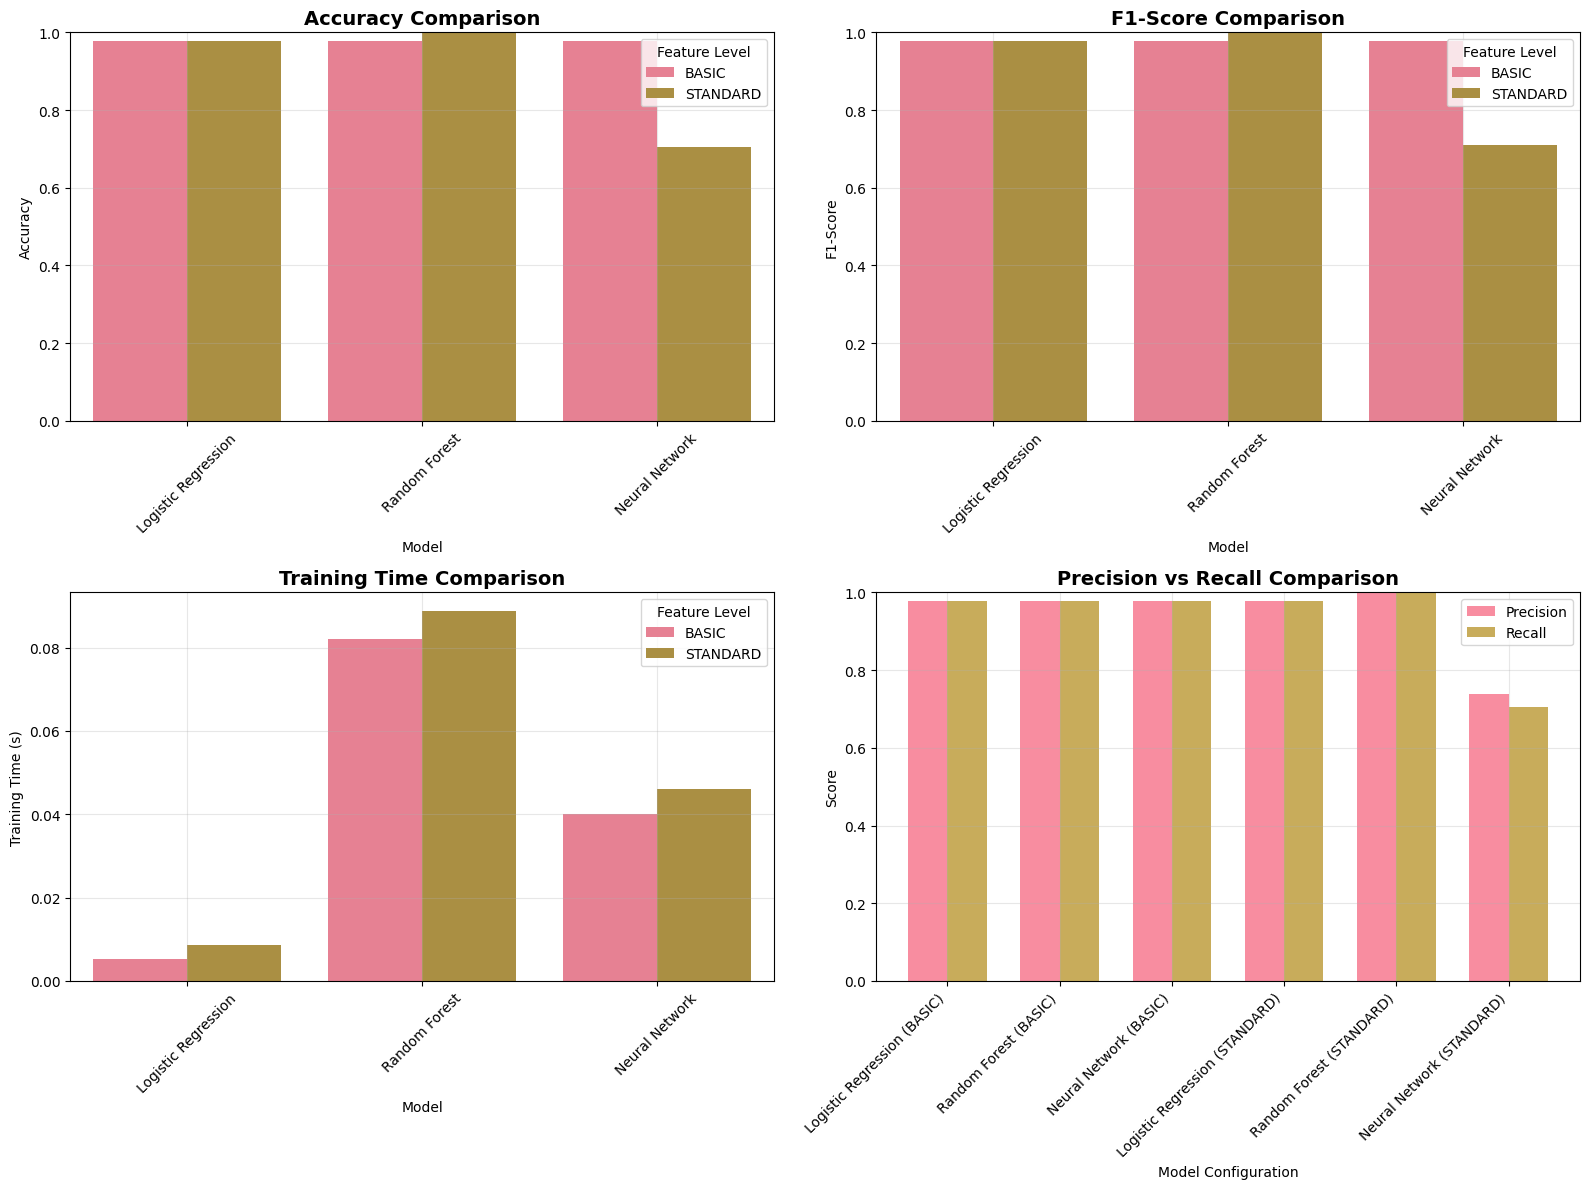

In [88]:
# 📊 Create visualization of results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for plotting
feature_levels = list(comparison_results.keys())
models = list(comparison_results[feature_levels[0]].keys())

# 1. Accuracy Comparison
accuracy_data = []
for fl in feature_levels:
    for model in models:
        accuracy_data.append({
            'Feature Level': fl.upper(), 
            'Model': model, 
            'Accuracy': comparison_results[fl][model]['accuracy']
        })
acc_df = pd.DataFrame(accuracy_data)

sns.barplot(data=acc_df, x='Model', y='Accuracy', hue='Feature Level', ax=ax1)
ax1.set_title('Accuracy Comparison', fontweight='bold', fontsize=14)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# 2. F1-Score Comparison  
f1_data = []
for fl in feature_levels:
    for model in models:
        f1_data.append({
            'Feature Level': fl.upper(), 
            'Model': model, 
            'F1-Score': comparison_results[fl][model]['f1']
        })
f1_df = pd.DataFrame(f1_data)

sns.barplot(data=f1_df, x='Model', y='F1-Score', hue='Feature Level', ax=ax2)
ax2.set_title('F1-Score Comparison', fontweight='bold', fontsize=14)
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Training Time Comparison
time_data = []
for fl in feature_levels:
    for model in models:
        time_data.append({
            'Feature Level': fl.upper(), 
            'Model': model, 
            'Training Time (s)': comparison_results[fl][model]['training_time']
        })
time_df = pd.DataFrame(time_data)

sns.barplot(data=time_df, x='Model', y='Training Time (s)', hue='Feature Level', ax=ax3)
ax3.set_title('Training Time Comparison', fontweight='bold', fontsize=14)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# 4. Precision vs Recall Bar Plot
prec_rec_data = []
for fl in feature_levels:
    for model in models:
        prec_rec_data.append({
            'Model': f"{model} ({fl.upper()})",
            'Precision': comparison_results[fl][model]['precision'],
            'Recall': comparison_results[fl][model]['recall'],
            'Feature Level': fl.upper()
        })
pr_df = pd.DataFrame(prec_rec_data)

# Create grouped bar plot
x = np.arange(len(pr_df))
width = 0.35

bars1 = ax4.bar(x - width/2, pr_df['Precision'], width, label='Precision', alpha=0.8)
bars2 = ax4.bar(x + width/2, pr_df['Recall'], width, label='Recall', alpha=0.8)

ax4.set_title('Precision vs Recall Comparison', fontweight='bold', fontsize=14)
ax4.set_xlabel('Model Configuration')
ax4.set_ylabel('Score')
ax4.set_xticks(x)
ax4.set_xticklabels(pr_df['Model'], rotation=45, ha='right')
ax4.set_ylim(0, 1)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# See above visualizations for performance comparison insights

---
## 🔍 Step 8.4: Feature Importance Analysis

Understanding which features contribute most to fault detection helps us:
1. **Interpret Model Decisions**: Know what the model is "listening for"
2. **Optimize Feature Sets**: Remove redundant features for faster inference
3. **Validate Physics**: Confirm model uses physically meaningful signals
4. **Guide Sensor Selection**: Focus on the most informative measurements

### 📊 Why Feature Importance Matters in Predictive Maintenance

In industrial settings, knowing which acoustic features detect faults allows you to:
- **Simplify Monitoring**: Focus on key features, reduce computational cost
- **Explain to Stakeholders**: Show maintenance teams what signals indicate failure
- **Design Better Sensors**: Optimize microphone placement and sampling rates
- **Cross-Domain Transfer**: Apply insights to similar equipment types

🔍 FEATURE IMPORTANCE ANALYSIS

📊 Analyzing: Random Forest with STANDARD features
   F1-Score: 1.000
   Method: Gini Importance

Total features: 443

🏆 Top 15 Most Important Features:
mfcc_5_mean                         │ ██  5.41%
mfcc_10_mean                        │ ██  5.10%
mfcc_7_mean                         │ ██  4.96%
quantile_25                         │ ██  4.65%
mean                                │ ██  4.53%
mfcc_9_mean                         │ ██  4.46%
energy                              │ ██  4.18%
std                                 │ █  3.96%
mfcc_6_mean                         │ █  3.66%
rms                                 │ █  3.22%
var                                 │ █  3.20%
chroma_mean                         │ █  3.15%
chroma_std                          │ █  3.12%
mfcc_12_mean                        │ █  2.78%
kurtosis                            │ █  2.74%


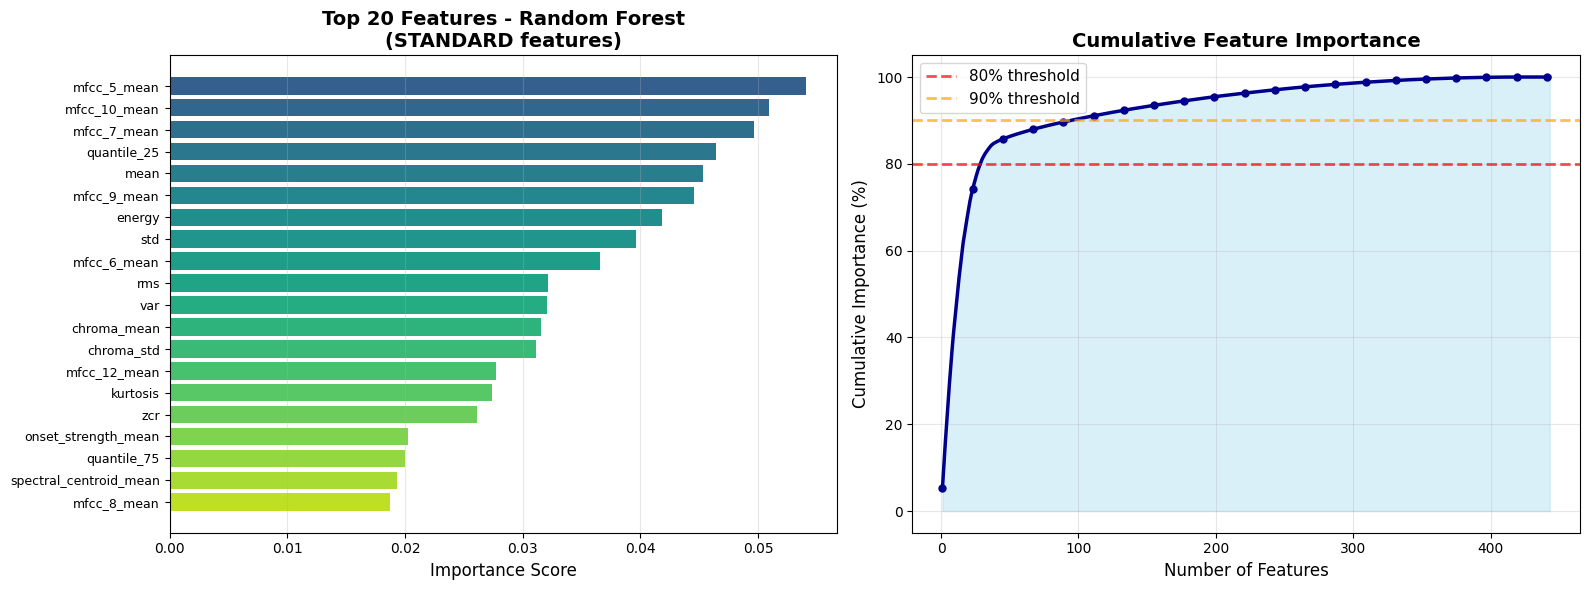


💡 Key Insights:
   • Total features: 443
   • Features for 80% importance: 29 (6.5%)
   • Features for 90% importance: 95 (21.4%)
   • Potential dimensionality reduction: 93.5%


In [89]:
# 🔍 Feature Importance Analysis

print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Determine which model performed best and analyze its feature importance
# Find the best performing model across all feature levels
best_model_info = None
best_f1 = 0

for feature_level, models in comparison_results.items():
    for model_name, metrics in models.items():
        if model_name == 'Random Forest' and metrics['f1'] > best_f1:
            best_f1 = metrics['f1']
            best_model_info = {
                'level': feature_level,
                'model': metrics['model'],
                'f1': metrics['f1'],
            }

print(f"\n📊 Analyzing: Random Forest with {best_model_info['level'].upper()} features")
print(f"   F1-Score: {best_model_info['f1']:.3f}")
print(f"   Method: Gini Importance\n")

# Get feature importance from the model
feature_importance = best_model_info['model'].feature_importances_
num_features = len(feature_importance)

# Generate feature names (we'll use generic names since we have many features)
feature_names_for_importance = comparison_results['standard']['Random Forest']['feature_names']
print(f"Total features: {num_features}\n")

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names_for_importance,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Display top 15 features
print(f"🏆 Top 15 Most Important Features:")
for idx, row in importance_df.head(15).iterrows():
    importance_pct = (row['Importance'] / importance_df['Importance'].sum()) * 100
    bar_length = int(importance_pct * 0.5)
    bar = '█' * bar_length
    print(f"{row['Feature']:35s} │ {bar} {importance_pct:5.2f}%")

# Visualize feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of top 20 features
top_n = min(20, len(importance_df))
top_features = importance_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))

ax1.barh(range(len(top_features)), top_features['Importance'], color=colors)
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features['Feature'], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Importance Score', fontsize=12)
ax1.set_title(f'Top {top_n} Features - Random Forest\n({best_model_info["level"].upper()} features)', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Cumulative importance curve
cumulative_importance = np.cumsum(importance_df['Importance'])
cumulative_importance_pct = (cumulative_importance / cumulative_importance.iloc[-1]) * 100

ax2.plot(range(1, len(cumulative_importance_pct) + 1), cumulative_importance_pct, 
         linewidth=2.5, color='darkblue', marker='o', markersize=5, markevery=max(1, len(cumulative_importance_pct)//20))
ax2.axhline(y=80, color='red', linestyle='--', linewidth=2, alpha=0.7, label='80% threshold')
ax2.axhline(y=90, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='90% threshold')
ax2.fill_between(range(1, len(cumulative_importance_pct) + 1), cumulative_importance_pct, 
                 alpha=0.3, color='skyblue')
ax2.set_xlabel('Number of Features', fontsize=12)
ax2.set_ylabel('Cumulative Importance (%)', fontsize=12)
ax2.set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Key insights
features_for_80pct = np.argmax(cumulative_importance_pct >= 80) + 1
features_for_90pct = np.argmax(cumulative_importance_pct >= 90) + 1

print(f"\n💡 Key Insights:")
print(f"   • Total features: {num_features}")
print(f"   • Features for 80% importance: {features_for_80pct} ({features_for_80pct/num_features*100:.1f}%)")
print(f"   • Features for 90% importance: {features_for_90pct} ({features_for_90pct/num_features*100:.1f}%)")
print(f"   • Potential dimensionality reduction: {100 - (features_for_80pct/num_features*100):.1f}%")


### 🤔 Reflection Questions & Exploration

#### 💭 Think About:

1. **Algorithm Selection Trade-offs**: Looking at the performance comparison table, why might certain algorithms (like Random Forest) outperform more complex models (like Neural Networks)? Consider factors such as dataset size, feature engineering quality, and the nature of the classification task in your answer.

2. **Feature Level Impact**: Compare the performance differences between BASIC and STANDARD features across all algorithms. Notice how different algorithms respond to richer feature representations - some show dramatic improvements while others remain stable. What does this tell you about which types of algorithms benefit most from more sophisticated feature engineering?

3. **Production Deployment Considerations**: Beyond accuracy and F1-score, examine the training time differences between algorithms. If you needed to retrain models regularly with new data in an industrial setting, how would computational cost factor into your decision? What if your dataset was 10x or 100x larger?

#### 🔬 Things to Try:

- **Feature Importance Validation**: Examine the feature importance chart to identify which features contribute most to predictions. Go back to Step 4.2 and look at the corresponding feature visualizations - can you interpret what physical or acoustic characteristics these important features might be capturing?

- **Segment Duration Impact**: Change the `segment_duration` parameter in Step 5 to different values (e.g., 2.0 or 10.0 seconds) and rerun the pipeline. How does this affect the number of training samples and model performance? What's the trade-off between temporal resolution and detection accuracy?

---
## 🎭 Step 9: Error Analysis via Confusion Matrix

The confusion matrix provides detailed error characterization, revealing classification patterns essential for deployment risk assessment and operational parameter tuning in industrial environments.

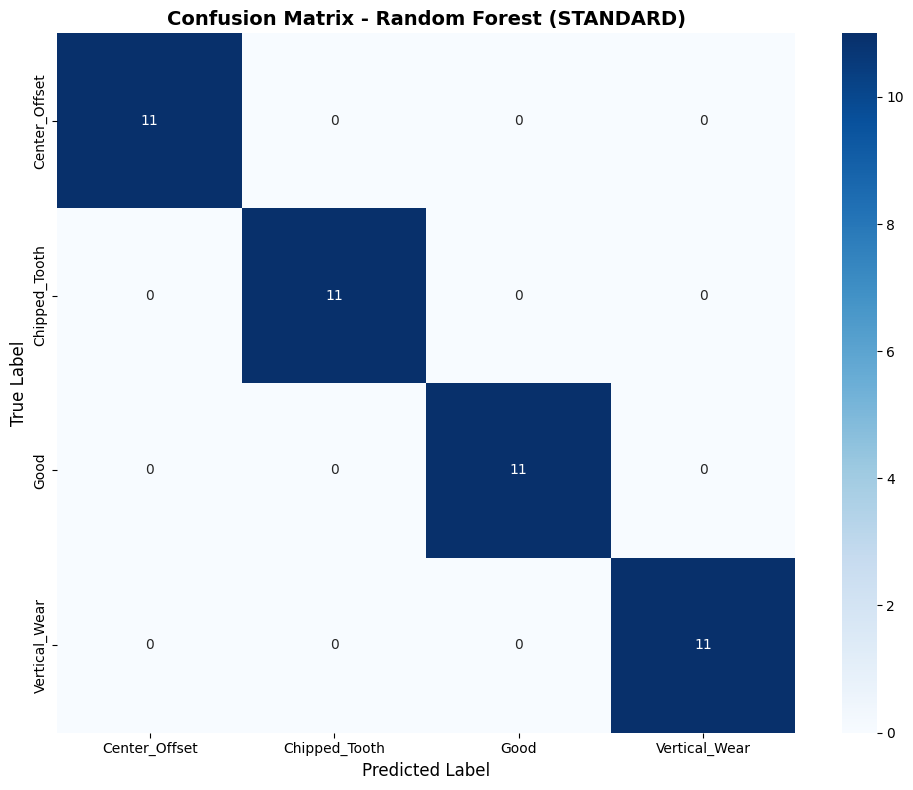


🎯 Model Performance Interpretation:
   📊 Diagonal values (darker): Correct predictions - want these HIGH
   ❌ Off-diagonal values: Mistakes - want these LOW


In [90]:
# 🎭 Create confusion matrix for the best model
# Use optimal_config which was already computed in the previous cell
best_feature_level, best_model_name = optimal_config
best_model_results = comparison_results[best_feature_level][best_model_name]

# Get predictions and true labels
y_pred = best_model_results['predictions']
y_test = best_model_results['y_test']
label_encoder = best_model_results['label_encoder']

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
class_names = label_encoder.classes_

# 📊 Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name} ({best_feature_level.upper()})', 
          fontweight='bold', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n🎯 Model Performance Interpretation:")
print(f"   📊 Diagonal values (darker): Correct predictions - want these HIGH")
print(f"   ❌ Off-diagonal values: Mistakes - want these LOW")


---
## 🎯 Step 10: Production Model Training

After validation-based model selection, the final step involves training the optimal configuration on the complete dataset to maximize performance for industrial deployment. This follows established machine learning deployment protocols.

### 💡 Why Retrain on All Data?
1. **📈 Maximum Performance**: Use every available sample for training
2. **🚀 Production Reality**: No "test set" in real deployment
3. **🔬 Validation Complete**: We've already proven the approach works
4. **🏭 Industry Standard**: Common practice for deployment models

### Production Training Methodology

1. **Dataset Consolidation**: Combine training and validation partitions for maximum sample utilization
2. **Performance Maximization**: Leverage all available data to optimize model parameters
3. **Deployment Readiness**: Create production-ready models without holdout constraints
4. **Validation Confidence**: Prior cross-validation ensures generalization capability


In [ ]:
# 🎯 Prepare final deployment model
import joblib
import os
from datetime import datetime


# 🏆 Find the best performing model combination across all tested configurations
best_f1 = 0                          # Track the highest F1 score achieved
best_combo = None                    # Store the (feature_level, model_name) combination that performed best
best_model_name = None               # Name of the best performing model type
best_score = 0                       # Store the best score for easy access

# Iterate through all combinations we tested (basic/standard/advanced × logistic/forest/neural)
for feature_level, models in comparison_results.items():    # Loop through feature complexity levels
    for model_name, metrics in models.items():              # Loop through model types within each feature level
        current_f1 = metrics['f1']                          # Get F1 score for this combination
        if current_f1 > best_f1:                            # If this is the best score we've seen
            best_f1 = current_f1                            # Update our best score
            best_combo = (feature_level, model_name)        # Remember which combination achieved it
            best_model_name = model_name                     # Store the model type for final training
            best_score = current_f1                          # Store score for reporting

print("🎯 Preparing Final Deployment Model...")
print(f"   🏆 Best combination: {best_model_name} with {best_combo[0].upper()} features (F1: {best_score:.3f})")

# 📊 Process complete dataset with best feature level
print("\\n📊 Processing complete dataset...")
complete_data = process_dataset(best_combo[0])  # best feature level

# 🔄 Combine ALL data (train + test) for final training - now that we know the best config, use all available data
X_all = np.vstack([complete_data['X_train'], complete_data['X_test']])      # Stack training and test features vertically
y_all = np.concatenate([complete_data['y_train'], complete_data['y_test']]) # Concatenate training and test labels

print(f"   ✅ Total samples: {len(X_all):,}")
print(f"   ✅ Total features: {X_all.shape[1]:,}")
print(f"   ✅ Classes: {np.unique(y_all)}")

# 🎯 Prepare final data (scaling and encoding) - create new preprocessors for deployment
final_scaler = StandardScaler()                    # Create scaler for deployment (will be saved with model)
X_all_scaled = final_scaler.fit_transform(X_all)   # Learn scaling parameters from ALL data and apply

final_label_encoder = LabelEncoder()               # Create label encoder for deployment (will be saved with model)
y_all_encoded = final_label_encoder.fit_transform(y_all)  # Learn label mapping from ALL classes and apply

print(f"\\n🔧 Data preparation complete:")
print(f"   📊 Scaled features: mean ≈ {np.mean(X_all_scaled):.3f}, std ≈ {np.std(X_all_scaled):.3f}")
print(f"   🏷️ Encoded labels: {dict(zip(final_label_encoder.classes_, range(len(final_label_encoder.classes_))))}")

# 🤖 Create and train final model (same type as best model) - instantiate the winning algorithm
if best_model_name == 'Logistic Regression':
    final_model = LogisticRegression(max_iter=1000, C=0.1, random_state=42)  # Linear classifier with regularization
elif best_model_name == 'Random Forest':
    final_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)  # Ensemble of decision trees
elif best_model_name == 'Neural Network':
    final_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42,         # Multi-layer neural network
                               early_stopping=True, validation_fraction=0.1)                           # with early stopping to prevent overfitting

print(f"\\n🤖 Training final {best_model_name} model...")
start_time = time.time()                        # Record training start time for performance monitoring
final_model.fit(X_all_scaled, y_all_encoded)   # Train the model on ALL available data (no holdout needed for deployment)
training_time = time.time() - start_time       # Calculate how long training took

print(f"   ✅ Training complete in {training_time:.2f} seconds")
print(f"   📊 Model trained on {len(X_all):,} samples")

# 💾 Save the deployment model and components
model_dir = Path("trained_models")
model_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f"pdm_model_{best_model_name.replace(' ', '_').lower()}_{best_combo[0]}_{timestamp}"

# Save all components needed for deployment
model_files = {
    'model': final_model,
    'scaler': final_scaler, 
    'label_encoder': final_label_encoder,
    'feature_names': complete_data['feature_names'],
    'feature_level': best_combo[0],
    'model_name': best_model_name,
    'training_info': {
        'timestamp': timestamp,
        'samples_used': len(X_all),
        'features_used': X_all.shape[1],
        'classes': list(final_label_encoder.classes_),
        'best_f1_score': best_score,
        'pipeline_params': {
            'segment_seconds': segment_duration,
            'overlap': overlap_ratio,
            'buffer_seconds': edge_buffer
        }
    }
}

# 💾 Save to file
model_path = model_dir / f"{model_filename}.pkl"
joblib.dump(model_files, model_path)

🎯 Preparing Final Deployment Model...
   🏆 Best combination: Random Forest with STANDARD features (F1: 1.000)
\n📊 Processing complete dataset...
🔄 Processing dataset with STANDARD features...
   ✅ Train samples: 376 segments
   ✅ Test samples: 44 segments
   ✅ Features per segment: 443
   ✅ Classes: ['Center_Offset' 'Chipped_Tooth' 'Good' 'Vertical_Wear']
   ✅ Total samples: 420
   ✅ Total features: 443
   ✅ Classes: ['Center_Offset' 'Chipped_Tooth' 'Good' 'Vertical_Wear']
\n🔧 Data preparation complete:
   📊 Scaled features: mean ≈ 0.000, std ≈ 1.000
   🏷️ Encoded labels: {np.str_('Center_Offset'): 0, np.str_('Chipped_Tooth'): 1, np.str_('Good'): 2, np.str_('Vertical_Wear'): 3}
\n🤖 Training final Random Forest model...
   ✅ Training complete in 0.08 seconds
   📊 Model trained on 420 samples


['trained_models/pdm_model_random_forest_standard_20251108_110824.pkl']

# Use the next block to download your model

In [ ]:
from google.colab import files
# 📥 Download model from Colab
files.download(str(model_path))

## 🧠 Step 11 & 🚀 Step 12: Model Persistence & Real-Time Deployment

The final two steps of this workshop—**Model Persistence** (loading and validating the saved model) and **Real-Time Deployment** (building a live monitoring system with production interface)—will be covered in a separate notebook.

This separation allows you to:
- **Practice deployment workflows** independently from training
- **Simulate production environments** where models are loaded from storage
- **Explore inference optimization** techniques without retraining
- **Build monitoring dashboards** for real-time fault detection

The deployment notebook will demonstrate how to load your trained model, process live audio streams, and create an interactive interface for industrial monitoring applications.